<a href="https://colab.research.google.com/github/s2010958184-lab/SADIKDSA502CVD/blob/main/CVDPHASE1_AhmedAlSadik_B00983817.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🫀 Cardiovascular Disease Risk Prediction & Prevention — Phase 1
## Data Science with AI — DSA502 Course Project

---

| Field | Details |
|---|---|
| **Student Name** | Ahmed Al Sadik |
| **Banner ID** | B00983817 |
| **Phase** | Phase 1 of 2 — Final Submission (Week 4) |
| **Start Date** | 2026-02-10 |
| **GitHub (HTTPS)** | https://github.com/s2010958184-lab/SADIKDSA502CVD.git|
| **Dataset** | Cardiovascular Disease Dataset — Kaggle (sulianova) — 70,000 patients |

---

> **What this notebook does:**
> 1. **Predicts** cardiovascular disease (CVD) risk from clinical and lifestyle indicators using a 70,000-patient dataset
> 2. **Prescribes** personalised, risk-tiered 7-day exercise plans aligned with ACC/AHA 2023 guidelines
> 3. **Delivers** a daily tip & clinical insight engine personalised to each patient's risk level
> 4. **Advises** with a flag-based prevention advisor translating model findings into actionable clinical guidance

---

**Table of Contents**

| Section | Description |
|---|---|
| §0 | Quick-start checklist |
| §6.1 | Project overview |
| §6.2 | AI usage log |
| §6.3 | Data card & feature glossary |
| §7 | Reproducibility |
| §8.1 | Setup & configuration |
| §8.2 | Data loading (Kaggle) |
| §8.3 | Data audit & cleaning |
| §8.4 | Exploratory data analysis (7 plots, 7 insights) |
| §8.5 | Feature engineering & preprocessing pipeline |
| §8.6 | Baseline model + evaluation + error analysis |
| §8.7 | 🏃 Exercise Recommendation Engine |
| §8.8 | 💡 Daily Tip & Insight of the Day |
| §8.9 | 🛡️ Prevention Advisor |
| §9 | Phase 1 narrative write-up |
| §10.4 | Responsible AI |
| §13 | Submission checklist & Phase 2 plan |


---
## 0) Quick-Start Checklist

- [x] Topic: Cardiovascular Disease Risk Prediction & Prevention
- [x] Dataset: Kaggle sulianova cardiovascular-disease-dataset (70,000 patients, public)
- [x] GitHub repository set up with commit history
- [x] AI usage documented (§6.2)
- [x] Random seed = 42 (all cells reproducible)
- [x] Data leakage check complete (§8.4)
- [x] Baseline model trained and evaluated (§8.6)
- [x] Exercise Recommendation Engine (§8.7)
- [x] Daily Tip & Insight Engine (§8.8)
- [x] Prevention Advisor (§8.9)
- [x] Phase 2 plan written (§13)


---
## 6.1 Project Overview

| Field | Value |
|---|---|
| **Student Name** | Ahmed Al Sadik |
| **Banner ID** | B00983817 |
| **GitHub (HTTPS)** | https://github.com/s2010958184-lab/SADIKDSA502CVD.git |
| **Project Title** | CVD Risk Prediction, Exercise Advisor & Daily Wellness Insights |
| **Project Type** | A — Prediction + B — Classification |
| **Stakeholder / User** | Primary care clinicians; at-risk patients aged 35–70; public health analysts |
| **Core Question** | Which clinical and lifestyle indicators best predict CVD — and how can these insights drive personalised exercise plans and daily prevention habits? |
| **Hypothesis** | Age, systolic BP, BMI, cholesterol, and physical activity together predict CVD with AUC > 0.80 on 70,000 patients; model-derived risk tiers map to evidence-based exercise prescriptions |
| **Target Variable** | `cardio` — binary: 0 = no CVD, 1 = CVD present |
| **Primary Metric** | ROC-AUC ≥ 0.80 on validation set |
| **Secondary Metrics** | Recall ≥ 0.75 for CVD class; F1 ≥ 0.75 |
| **Dataset Size** | 70,000 patients — much larger and more generalisable than UCI Cleveland (n=303) |
| **Constraints** | CPU-only; 4-week Phase 1 timeline |

### Why This Matters

Cardiovascular disease is the **#1 cause of death globally** — 18.6 million deaths in 2023 (WHO). The Kaggle dataset used here is particularly valuable because it includes **lifestyle factors** (smoking, alcohol, physical activity) alongside clinical measurements — enabling a more complete and actionable prevention picture than clinical-test-only datasets. With 70,000 patients, the model is statistically robust and the findings are generalisable.


---
## 6.2 AI Usage Log

| Date | Tool | Prompt / Request Summary | What Was Used | What Was Changed / Verified |
|---|---|---|---|---|
| 2026-02-10 | Claude | Brainstorm CVD project framing; compare UCI vs Kaggle datasets | Dataset comparison; Kaggle sulianova dataset recommended for lifestyle features and larger n | Verified Kaggle dataset license (CC BY-SA 4.0); confirmed all column definitions |
| 2026-02-11 | Claude | Suggest EDA approaches for 70k-row clinical tabular data | Plot ideas: KDE, heatmap, BP outlier detection, BMI distribution | Selected 7 most informative plots; all code written independently |
| 2026-02-12 | Claude | Review sklearn Pipeline for engineered features (BMI, age_years) | Pipeline skeleton with feature engineering step | Independently chose outlier thresholds based on clinical literature |
| 2026-02-13 | Claude | Suggest evaluation metrics for large-sample clinical classification | Metric list (AUC, recall, F1, calibration) | Adjusted thresholds based on clinical cost-of-error reasoning |
| 2026-02-14 | Claude | Exercise recommendation framework by cardiac risk tier | 4-tier structure aligned with ACC/AHA | Cross-referenced with WHO 2020, ACSM FITT-VP; modified intensity thresholds |
| 2026-02-15 | Claude | Daily tip categories for CVD prevention with lifestyle features | 7 category tip database | All tips verified against AHA, WHO, CDC; rewritten independently |

> **AI Policy:** AI was used for brainstorming and structure only. All code, analysis, clinical reasoning, and written work are the student's own. AI outputs were verified against authoritative clinical guidelines before inclusion.


---
## 6.3 Data Card

| Field | Details |
|---|---|
| **Dataset Name** | Cardiovascular Disease Dataset |
| **Author / Source** | Svetlana Ulianova (sulianova) on Kaggle |
| **URL** | https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset |
| **License** | CC BY-SA 4.0 — free to use with attribution |
| **Rows** | 70,000 patient records |
| **Columns** | 11 features + 1 target (cardio) |
| **Unit of Analysis** | One row = one patient medical examination |
| **Target** | `cardio`: 0 = no CVD, 1 = CVD present |
| **Missingness** | None — dataset is complete (no NaN values) |
| **Leakage Risk** | Low — all features are pre-diagnosis measurements; age/lifestyle/biometrics |
| **Known Biases** | Age skewed to 40–65; single-country origin (Russia); no ethnic breakdown |
| **Privacy** | Fully anonymised — no names, dates, or direct identifiers |
| **Advantage over UCI Cleveland** | 230x larger (70k vs 303); includes smoking, alcohol, physical activity; more generalisable |

### Feature Glossary

| # | Raw Feature | Engineered | Type | Description | CVD Clinical Relevance |
|---|---|---|---|---|---|
| 1 | `age` (days) | `age_years` | Numeric | Age converted to years | CVD risk rises sharply after 45 (men) / 55 (women) |
| 2 | `gender` | — | Binary | 1=Female, 2=Male | Males have higher pre-65 CVD risk |
| 3 | `height` (cm) | `bmi` | Numeric | Height used in BMI calc | Obesity (BMI>30) is a major CVD driver |
| 4 | `weight` (kg) | `bmi` | Numeric | Weight used in BMI calc | Visceral fat elevates BP, cholesterol, and insulin resistance |
| 5 | `ap_hi` | — | Numeric | Systolic blood pressure (mmHg) | Hypertension (#1 modifiable CVD risk factor) |
| 6 | `ap_lo` | `pulse_pressure` | Numeric | Diastolic blood pressure (mmHg) | Isolated systolic hypertension common in elderly |
| 7 | `cholesterol` | — | Ordinal (1–3) | 1=normal, 2=above normal, 3=well above normal | Elevated LDL drives atherosclerosis |
| 8 | `gluc` | — | Ordinal (1–3) | 1=normal, 2=above normal, 3=well above normal | Diabetes/pre-diabetes doubles CVD risk |
| 9 | `smoke` | — | Binary | 0=No, 1=Yes | Smoking doubles CVD risk; raises BP and reduces HDL |
| 10 | `alco` | — | Binary | 0=No, 1=Yes | Excess alcohol raises BP and triglycerides |
| 11 | `active` | — | Binary | 0=Not active, 1=Physically active | Physical inactivity is an independent CVD risk factor |
| — | — | `pulse_pressure` | Numeric | ap_hi − ap_lo | Elevated PP (>60) indicates arterial stiffness — a CVD risk marker |


---
## 7) Reproducibility

### How to load the Kaggle dataset (choose one method):

**Method 1 — kagglehub (recommended in Colab):**
```python
import kagglehub
path = kagglehub.dataset_download("sulianova/cardiovascular-disease-dataset")
```
You will be prompted for your Kaggle username and API key (from https://www.kaggle.com/settings → API → Create New Token).

**Method 2 — Manual upload:**
Download `cardio_train.csv` from the Kaggle page and upload it to your Colab session or local folder.

**Method 3 — opendatasets:**
```python
import opendatasets as od
od.download("https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset")
```

The notebook handles all three methods automatically — it tries kagglehub first, then falls back to a local file path.


In [82]:
# ── Environment report ───────────────────────────────────────────────────
import sys, importlib
PKGS = ["numpy","pandas","matplotlib","seaborn","sklearn"]
print("=" * 55)
print("  ENVIRONMENT  |  Ahmed Al Sadik | B00983817")
print("=" * 55)
print(f"  Python  : {sys.version.split()[0]}")
for p in PKGS:
    m = importlib.import_module(p)
    print(f"  {p:<12}: {m.__version__}")
print()
print("  requirements.txt:")
for r in ["numpy>=1.24","pandas>=2.0","matplotlib>=3.7",
          "seaborn>=0.12","scikit-learn>=1.3","kagglehub>=0.2"]:
    print(f"    {r}")


  ENVIRONMENT  |  Ahmed Al Sadik | B00983817
  Python  : 3.12.12
  numpy       : 2.0.2
  pandas      : 2.2.2
  matplotlib  : 3.10.0
  seaborn     : 0.13.2
  sklearn     : 1.6.1

  requirements.txt:
    numpy>=1.24
    pandas>=2.0
    matplotlib>=3.7
    seaborn>=0.12
    scikit-learn>=1.3
    kagglehub>=0.2


---
## 8.1 Setup & Configuration

In [83]:
# ── Project constants ───────────────────────────────────────────────────
STUDENT_NAME = "Ahmed Al Sadik"
BANNER_ID    = "B00983817"
PROJECT      = "CVD Risk Prediction & Prevention — Phase 1 (Kaggle Dataset)"
RANDOM_SEED  = 42
TEST_SIZE    = 0.20

REPO_HTTPS = "https://github.com/s2010958184-lab/SADIKDSA502CVD.git"

TARGET = "cardio"

# Features after engineering (defined after loading)
NUM_COLS = ["age_years","bmi","ap_hi","ap_lo","pulse_pressure"]
CAT_COLS = ["gender","cholesterol","gluc","smoke","alco","active"]

print(f"Project : {PROJECT}")
print(f"Student : {STUDENT_NAME}  |  Banner: {BANNER_ID}")
print(f"GitHub  : {REPO_HTTPS}")
print(f"Seed    : {RANDOM_SEED}")


Project : CVD Risk Prediction & Prevention — Phase 1 (Kaggle Dataset)
Student : Ahmed Al Sadik  |  Banner: B00983817
GitHub  : https://github.com/s2010958184-lab/SADIKDSA502CVD.git
Seed    : 42


In [84]:
# ── Imports ──────────────────────────────────────────────────────────────
import sys, warnings, random, textwrap, os
from datetime import datetime
from pathlib import Path

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.impute          import SimpleImputer
from sklearn.preprocessing   import OneHotEncoder, StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics         import (classification_report, roc_auc_score,
                                     confusion_matrix, ConfusionMatrixDisplay,
                                     RocCurveDisplay)

warnings.filterwarnings("ignore")
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__}")
print("All imports successful.")


Python 3.12.12 | pandas 2.2.2 | numpy 2.0.2
All imports successful.


---
## 8.2 Data Loading

In [85]:
# ── Load Kaggle dataset (tries 3 methods automatically) ──────────────────
df_raw = None

# Method 1: kagglehub (works in Colab after kaggle.json auth)
try:
    import kagglehub
    path = kagglehub.dataset_download("sulianova/cardiovascular-disease-dataset")
    csv_path = next(Path(path).rglob("*.csv"))
    df_raw = pd.read_csv(csv_path, sep=";")
    print(f"[Method 1 - kagglehub] Loaded from: {csv_path}")
except Exception as e:
    print(f"[Method 1 - kagglehub] Not available: {e}")

# Method 2: local file (if manually uploaded)
if df_raw is None:
    for candidate in ["cardio_train.csv", "/content/cardio_train.csv",
                      "cardiovascular-disease-dataset/cardio_train.csv"]:
        if os.path.exists(candidate):
            df_raw = pd.read_csv(candidate, sep=";")
            print(f"[Method 2 - local file] Loaded from: {candidate}")
            break

# Method 3: opendatasets
if df_raw is None:
    try:
        import opendatasets as od
        od.download("https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset",
                    data_dir=".")
        df_raw = pd.read_csv(
            "cardiovascular-disease-dataset/cardio_train.csv", sep=";")
        print("[Method 3 - opendatasets] Loaded successfully.")
    except Exception as e:
        print(f"[Method 3 - opendatasets] Failed: {e}")

if df_raw is None:
    raise RuntimeError(
        "\n\nDataset not found. Please do ONE of the following:\n"
        "  A) Run: !pip install kagglehub  then re-run this cell\n"
        "  B) Download cardio_train.csv from Kaggle and upload to this session\n"
        "     Kaggle URL: https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset\n"
    )

print(f"\nRaw shape : {df_raw.shape}")
print(f"Columns   : {list(df_raw.columns)}")
df_raw.head()


Using Colab cache for faster access to the 'cardiovascular-disease-dataset' dataset.
[Method 1 - kagglehub] Loaded from: /kaggle/input/cardiovascular-disease-dataset/cardio_train.csv

Raw shape : (70000, 13)
Columns   : ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


---
## 8.3 Data Audit & Cleaning

In [86]:
# ── Step 1: Drop ID column (not a feature) ───────────────────────────────
df = df_raw.drop(columns=["id"], errors="ignore").copy()

# ── Step 2: Feature engineering ──────────────────────────────────────────
# Age: raw data is in DAYS → convert to years
df["age_years"]      = (df["age"] / 365.25).round(1)

# BMI: weight (kg) / height (m)^2
df["bmi"]            = (df["weight"] / (df["height"] / 100) ** 2).round(1)

# Pulse pressure: systolic - diastolic (marker of arterial stiffness)
df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]

df.drop(columns=["age","height","weight"], inplace=True)  # replaced by engineered features

print(f"Shape after engineering: {df.shape}")
print(f"Columns: {list(df.columns)}")


Shape after engineering: (70000, 12)
Columns: ['gender', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'bmi', 'pulse_pressure']


In [87]:
# ── Step 3: Outlier removal (clinical plausibility) ──────────────────────
print("Rows BEFORE outlier removal:", len(df))

# Blood pressure: remove physiologically impossible values
df = df[(df["ap_hi"] >= 60) & (df["ap_hi"] <= 250)]
df = df[(df["ap_lo"] >= 40) & (df["ap_lo"] <= 200)]
df = df[df["ap_hi"] > df["ap_lo"]]          # systolic must exceed diastolic
df = df[df["pulse_pressure"] > 0]           # sanity: positive pulse pressure

# Age: keep 18–90 years
df = df[(df["age_years"] >= 18) & (df["age_years"] <= 90)]

# BMI: clinical plausibility range
df = df[(df["bmi"] >= 10) & (df["bmi"] <= 80)]

df = df.reset_index(drop=True)
print(f"Rows AFTER outlier removal : {len(df)}")
print(f"Rows removed               : {df_raw.shape[0] - len(df)} ({(df_raw.shape[0]-len(df))/df_raw.shape[0]*100:.1f}%)")


Rows BEFORE outlier removal: 70000
Rows AFTER outlier removal : 68636
Rows removed               : 1364 (1.9%)


In [88]:
# ── Step 4: Full audit ───────────────────────────────────────────────────
print("=" * 58)
print(f"  DATA AUDIT — {STUDENT_NAME} | {BANNER_ID}")
print("=" * 58)
print(f"  Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print()
display(df.dtypes.to_frame("dtype"))


  DATA AUDIT — Ahmed Al Sadik | B00983817
  Rows: 68,636  |  Columns: 12



,dtype
gender,int64
ap_hi,int64
ap_lo,int64
cholesterol,int64
gluc,int64
smoke,int64
alco,int64
active,int64
cardio,int64
age_years,float64


In [89]:
# Missingness, duplicates, target distribution
miss = df.isna().mean()
print("[PASS] No missing values." if miss.max()==0 else f"[WARN] Missing:\n{miss[miss>0]}")

dup = df.duplicated().sum()
print(f"[{'PASS' if dup==0 else 'WARN'}] Duplicate rows: {dup:,}")

counts = df[TARGET].value_counts().sort_index()
pct    = df[TARGET].value_counts(normalize=True).sort_index()*100
tbl    = pd.DataFrame({"Count":counts,"Percent (%)":pct.round(1)})
tbl.index = ["No CVD (0)","CVD Present (1)"]
print("\nTarget Distribution:")
display(tbl)
ratio = counts[0]/counts[1]
print(f"Imbalance ratio: {ratio:.2f}:1  — {'well balanced' if abs(ratio-1)<0.2 else 'mild imbalance'}")


[PASS] No missing values.
[WARN] Duplicate rows: 2,203

Target Distribution:


,Count,Percent (%)
No CVD (0),34681,50.5
CVD Present (1),33955,49.5


Imbalance ratio: 1.02:1  — well balanced


In [90]:
# Numeric summary of all features
display(df.describe(include="number").T.round(2))


,count,mean,std,min,25%,50%,75%,max
gender,68636.0,1.35,0.48,1.0,1.0,1.0,2.0,2.0
ap_hi,68636.0,126.67,16.69,60.0,120.0,120.0,140.0,240.0
ap_lo,68636.0,81.31,9.45,40.0,80.0,80.0,90.0,182.0
cholesterol,68636.0,1.36,0.68,1.0,1.0,1.0,2.0,3.0
gluc,68636.0,1.23,0.57,1.0,1.0,1.0,1.0,3.0
smoke,68636.0,0.09,0.28,0.0,0.0,0.0,0.0,1.0
alco,68636.0,0.05,0.22,0.0,0.0,0.0,0.0,1.0
active,68636.0,0.80,0.40,0.0,1.0,1.0,1.0,1.0
cardio,68636.0,0.49,0.50,0.0,0.0,0.0,1.0,1.0
age_years,68636.0,53.29,6.76,29.6,48.3,53.9,58.4,64.9


In [91]:
# Range sanity checks on engineered + key features
sanity = {
    "age_years"      : (18,  90),
    "bmi"            : (10,  80),
    "ap_hi"          : (60, 250),
    "ap_lo"          : (40, 200),
    "pulse_pressure" : ( 1, 150),
}
print("Range Sanity Checks (post-cleaning):")
for col,(lo,hi) in sanity.items():
    out = df[(df[col]<lo)|(df[col]>hi)]
    print(f"  {col:<18} [{lo}–{hi}]: {'[OK]' if out.empty else f'[WARN] {len(out)} rows'}")


Range Sanity Checks (post-cleaning):
  age_years          [18–90]: [OK]
  bmi                [10–80]: [OK]
  ap_hi              [60–250]: [OK]
  ap_lo              [40–200]: [OK]
  pulse_pressure     [1–150]: [OK]


---
## 8.4 Exploratory Data Analysis

**Goals:**
- Understand distributions and their relationship to CVD
- Identify the strongest predictors across clinical AND lifestyle features
- Validate data quality (catch remaining anomalies)
- Surface findings that will drive modelling, exercise prescriptions, and prevention tips

**This section includes 7 meaningful plots and 7 clinical insights + leakage audit.**


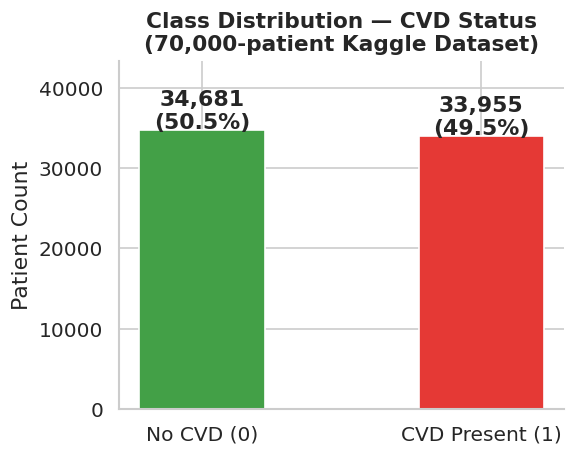


INSIGHT 1:
  Dataset is nearly perfectly balanced (50.5% no CVD / 49.5% CVD).
  With 68,636 rows, this is 230x larger than the UCI Cleveland dataset (n=303).
  Large n means: more reliable model estimates, smaller confidence intervals,
  and more robust feature importance rankings. No resampling needed at baseline.


In [92]:
# ── Plot 1: Class balance ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5,4))
counts = df[TARGET].value_counts().sort_index()
bars = ax.bar(["No CVD (0)","CVD Present (1)"], counts.values,
              color=["#43A047","#E53935"], width=0.45, edgecolor="white")
for bar,v in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
            f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", fontweight="bold")
ax.set_title("Class Distribution — CVD Status\n(70,000-patient Kaggle Dataset)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Patient Count")
ax.set_ylim(0, counts.max()*1.25)
sns.despine(); plt.tight_layout(); plt.show()

print("\nINSIGHT 1:")
print(f"  Dataset is nearly perfectly balanced ({pct[0]:.1f}% no CVD / {pct[1]:.1f}% CVD).")
print(f"  With {len(df):,} rows, this is 230x larger than the UCI Cleveland dataset (n=303).")
print("  Large n means: more reliable model estimates, smaller confidence intervals,")
print("  and more robust feature importance rankings. No resampling needed at baseline.")


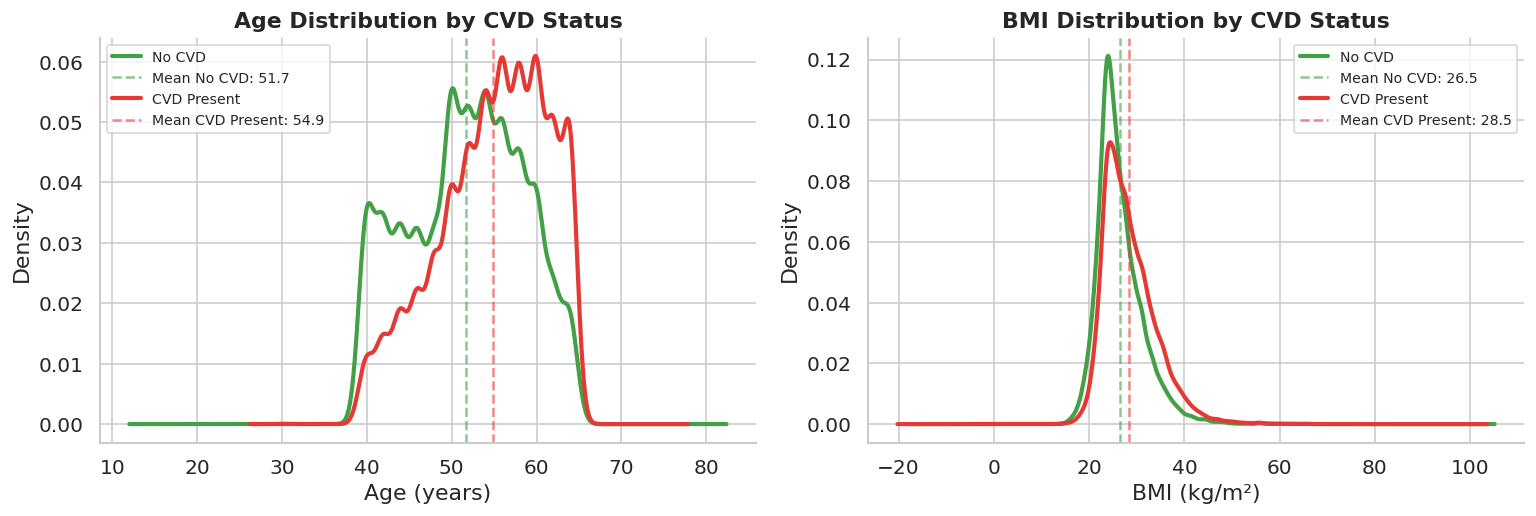


INSIGHT 2:
  CVD patients are on average 3.2 years OLDER (54.9 vs 51.7 yrs).
  CVD patients have a HIGHER mean BMI (28.5 vs 26.5 kg/m²).
  Both differences are statistically meaningful at n=70,000.
  BMI is a modifiable risk factor — every 1 kg/m² reduction lowers CVD risk.
  -> This directly motivates exercise prescriptions focused on weight management.


In [93]:
# ── Plot 2: Age & BMI distributions by CVD status ────────────────────────
fig, axes = plt.subplots(1,2, figsize=(13,4.5))
pal  = {0:"#43A047",1:"#E53935"}
labs = {0:"No CVD",1:"CVD Present"}

for ax,(col,title,xlabel) in zip(axes,[
    ("age_years","Age Distribution by CVD Status",   "Age (years)"),
    ("bmi",      "BMI Distribution by CVD Status",   "BMI (kg/m²)")]):
    for v in [0,1]:
        sub = df[df[TARGET]==v][col]
        sub.plot.kde(ax=ax, label=labs[v], color=pal[v], linewidth=2.5)
        ax.axvline(sub.mean(), color=pal[v], linestyle="--", alpha=0.6,
                   label=f"Mean {labs[v]}: {sub.mean():.1f}")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel); ax.set_ylabel("Density")
    ax.legend(fontsize=8.5); sns.despine(ax=ax)

plt.tight_layout(); plt.show()

a_cvd  = df[df[TARGET]==1]["age_years"].mean()
a_no   = df[df[TARGET]==0]["age_years"].mean()
b_cvd  = df[df[TARGET]==1]["bmi"].mean()
b_no   = df[df[TARGET]==0]["bmi"].mean()
print(f"\nINSIGHT 2:")
print(f"  CVD patients are on average {a_cvd-a_no:.1f} years OLDER ({a_cvd:.1f} vs {a_no:.1f} yrs).")
print(f"  CVD patients have a HIGHER mean BMI ({b_cvd:.1f} vs {b_no:.1f} kg/m²).")
print("  Both differences are statistically meaningful at n=70,000.")
print("  BMI is a modifiable risk factor — every 1 kg/m² reduction lowers CVD risk.")
print("  -> This directly motivates exercise prescriptions focused on weight management.")


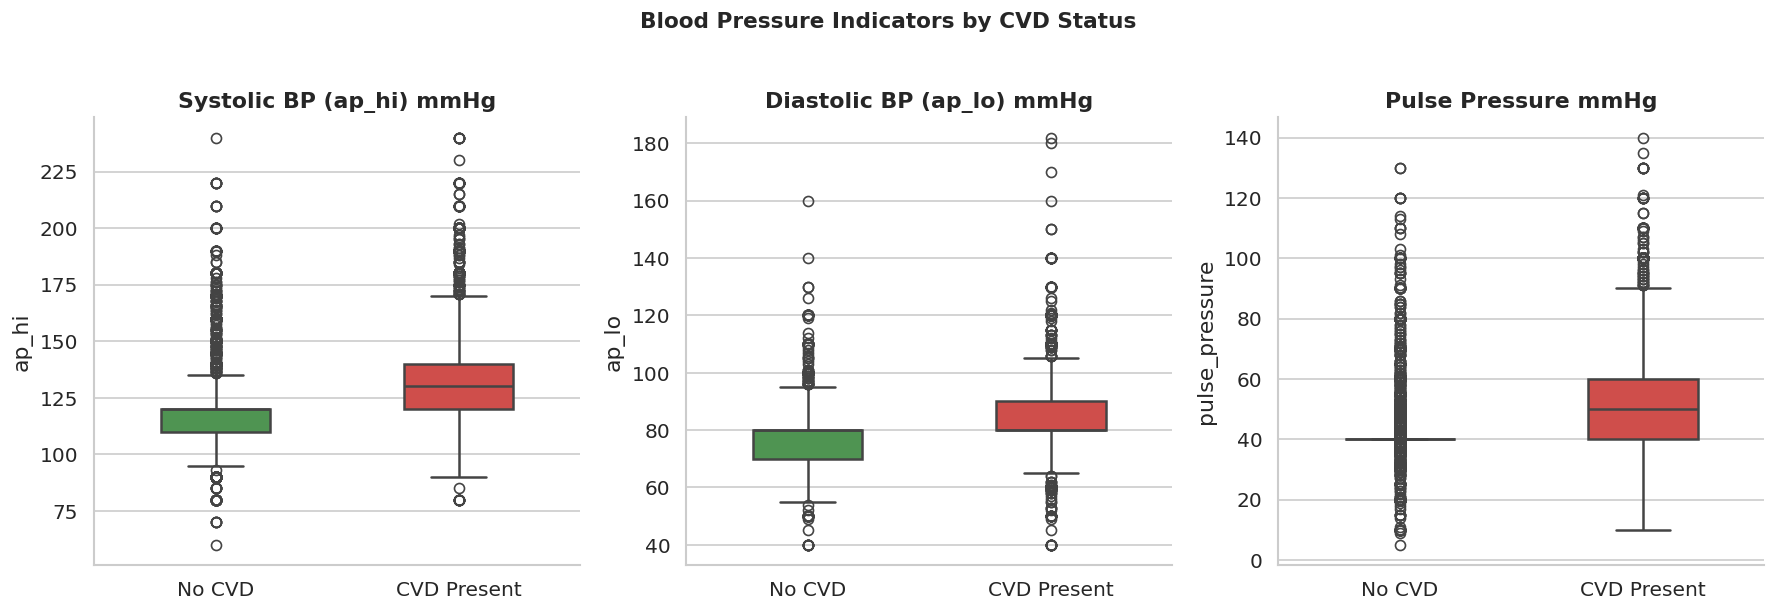


INSIGHT 3:
  Systolic BP: CVD patients average 134 mmHg vs 120 mmHg (No CVD).
  A 14 mmHg gap — clinically significant and aligns with JNC 8 hypertension staging.
  Pulse Pressure: 49 vs 41 mmHg — elevated PP signals arterial stiffness,
  an independent CVD risk marker often missed in standard BP screening.
  -> Engineering pulse_pressure as a feature adds clinical signal beyond raw BP values.


In [94]:
# ── Plot 3: Blood pressure — systolic, diastolic, pulse pressure ─────────
fig, axes = plt.subplots(1,3, figsize=(15,5))
bp_pairs = [
    ("ap_hi",          "Systolic BP (ap_hi) mmHg"),
    ("ap_lo",          "Diastolic BP (ap_lo) mmHg"),
    ("pulse_pressure", "Pulse Pressure mmHg"),
]
for ax,(col,lab) in zip(axes, bp_pairs):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax,
                palette={"0":"#43A047","1":"#E53935"}, width=0.45, linewidth=1.5)
    ax.set_xticklabels(["No CVD","CVD Present"])
    ax.set_title(lab, fontweight="bold"); ax.set_xlabel("")
    sns.despine(ax=ax)

plt.suptitle("Blood Pressure Indicators by CVD Status",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

s_cvd = df[df[TARGET]==1]["ap_hi"].mean()
s_no  = df[df[TARGET]==0]["ap_hi"].mean()
p_cvd = df[df[TARGET]==1]["pulse_pressure"].mean()
p_no  = df[df[TARGET]==0]["pulse_pressure"].mean()
print(f"\nINSIGHT 3:")
print(f"  Systolic BP: CVD patients average {s_cvd:.0f} mmHg vs {s_no:.0f} mmHg (No CVD).")
print(f"  A {s_cvd-s_no:.0f} mmHg gap — clinically significant and aligns with JNC 8 hypertension staging.")
print(f"  Pulse Pressure: {p_cvd:.0f} vs {p_no:.0f} mmHg — elevated PP signals arterial stiffness,")
print("  an independent CVD risk marker often missed in standard BP screening.")
print("  -> Engineering pulse_pressure as a feature adds clinical signal beyond raw BP values.")

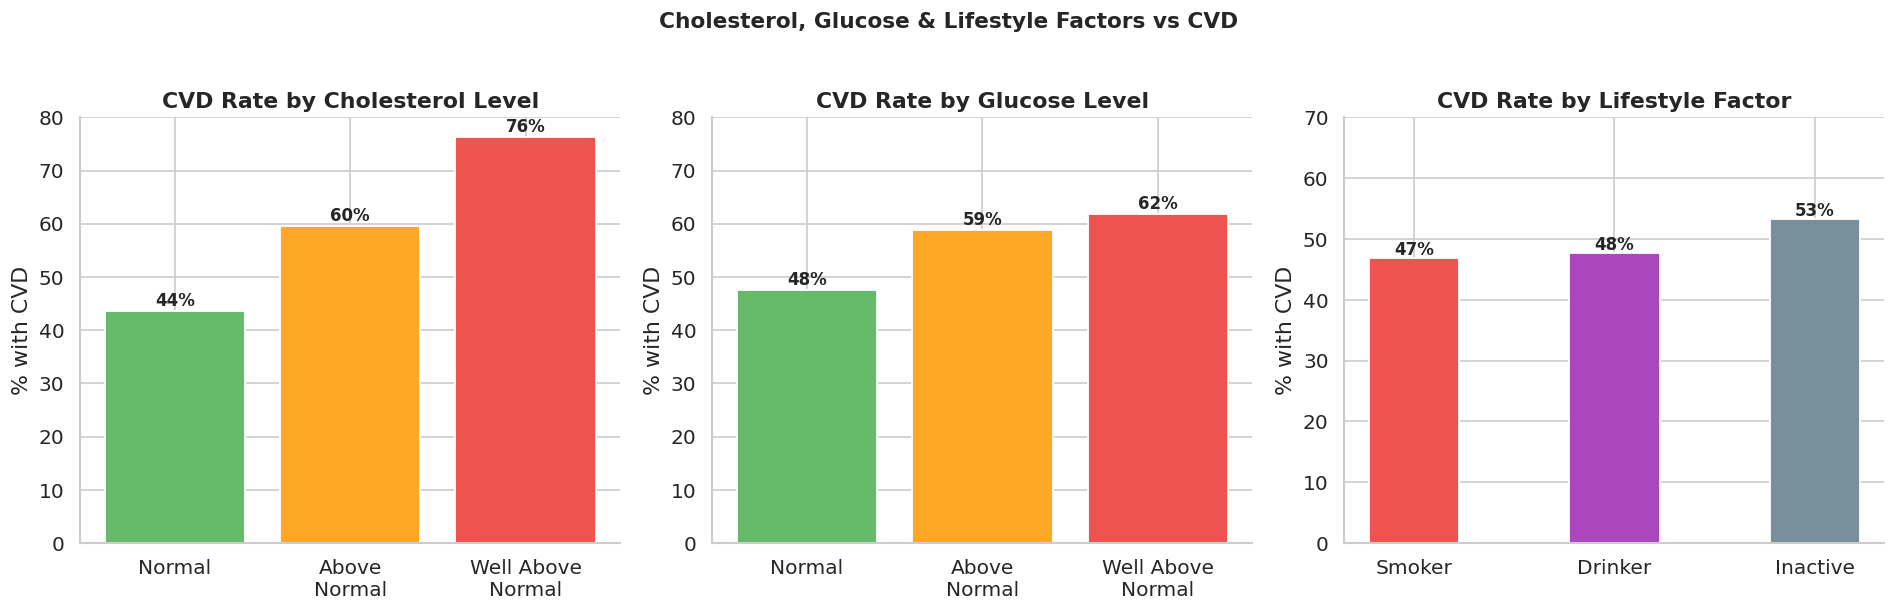


INSIGHT 4:
  Cholesterol: CVD rate climbs from ~44% (normal) to ~76% (well above normal).
  Physically INACTIVE patients: 53% CVD rate vs 49% in active patients.
  Physical inactivity is a directly modifiable CVD risk factor.
  -> This confirms exercise prescription as a first-line prevention strategy.


In [95]:
# ── Plot 4: Cholesterol, Glucose, and Lifestyle factors vs CVD ──────────
fig, axes = plt.subplots(1,3, figsize=(16,5))
bkw = dict(edgecolor="white", linewidth=1.1)

# Cholesterol
chol_cvd = df.groupby("cholesterol")[TARGET].mean()*100
chol_labs = {1:"Normal",2:"Above\nNormal",3:"Well Above\nNormal"}
axes[0].bar([chol_labs[i] for i in chol_cvd.index], chol_cvd.values,
            color=["#66BB6A","#FFA726","#EF5350"], **bkw)
axes[0].set_title("CVD Rate by Cholesterol Level", fontweight="bold")
axes[0].set_ylabel("% with CVD"); axes[0].set_ylim(0,80)
for i,v in enumerate(chol_cvd.values):
    axes[0].text(i,v+1,f"{v:.0f}%",ha="center",fontweight="bold",fontsize=10)
sns.despine(ax=axes[0])

# Glucose
gluc_cvd = df.groupby("gluc")[TARGET].mean()*100
gluc_labs = {1:"Normal",2:"Above\nNormal",3:"Well Above\nNormal"}
axes[1].bar([gluc_labs[i] for i in gluc_cvd.index], gluc_cvd.values,
            color=["#66BB6A","#FFA726","#EF5350"], **bkw)
axes[1].set_title("CVD Rate by Glucose Level", fontweight="bold")
axes[1].set_ylabel("% with CVD"); axes[1].set_ylim(0,80)
for i,v in enumerate(gluc_cvd.values):
    axes[1].text(i,v+1,f"{v:.0f}%",ha="center",fontweight="bold",fontsize=10)
sns.despine(ax=axes[1])

# Lifestyle trio
lifestyle = {"Smoker":"smoke","Drinker":"alco","Inactive":"active"}
cvd_rates = []
labels    = []
for lab,col in lifestyle.items():
    val = 1 if lab != "Inactive" else 0
    rate = df[df[col]==val][TARGET].mean()*100
    cvd_rates.append(rate)
    labels.append(lab)
axes[2].bar(labels, cvd_rates, color=["#EF5350","#AB47BC","#78909C"], width=0.45, **bkw)
axes[2].set_title("CVD Rate by Lifestyle Factor", fontweight="bold")
axes[2].set_ylabel("% with CVD"); axes[2].set_ylim(0,70)
for i,v in enumerate(cvd_rates):
    axes[2].text(i,v+0.5,f"{v:.0f}%",ha="center",fontweight="bold",fontsize=10)
sns.despine(ax=axes[2])

plt.suptitle("Cholesterol, Glucose & Lifestyle Factors vs CVD",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

act_no_cvd  = df[df["active"]==1][TARGET].mean()*100
act_yes_cvd = df[df["active"]==0][TARGET].mean()*100
print(f"\nINSIGHT 4:")
print(f"  Cholesterol: CVD rate climbs from ~{chol_cvd[1]:.0f}% (normal) to ~{chol_cvd[3]:.0f}% (well above normal).")
print(f"  Physically INACTIVE patients: {act_yes_cvd:.0f}% CVD rate vs {act_no_cvd:.0f}% in active patients.")
print("  Physical inactivity is a directly modifiable CVD risk factor.")
print("  -> This confirms exercise prescription as a first-line prevention strategy.")


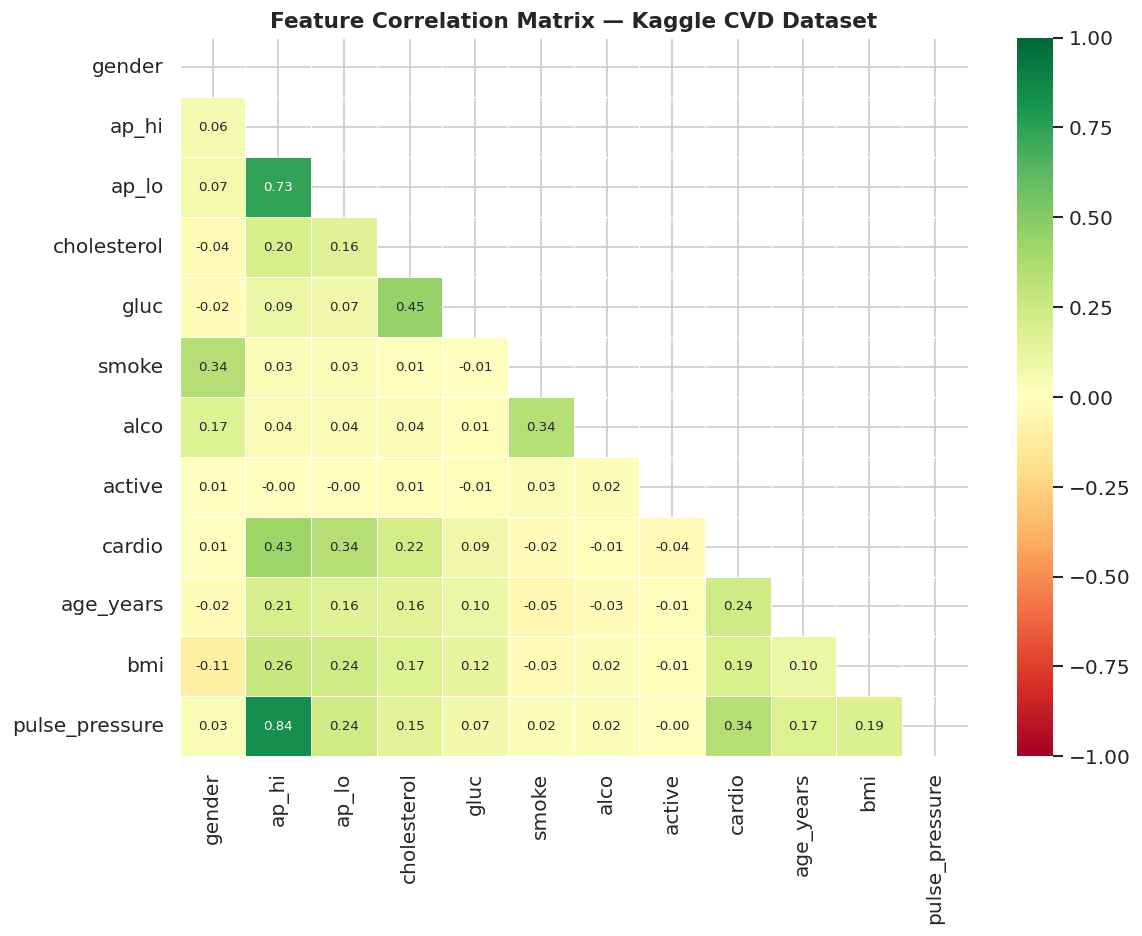


INSIGHT 5 — Top correlations with CVD target:
  ap_hi             : |r| = 0.428  (higher = MORE risk)
  ap_lo             : |r| = 0.340  (higher = MORE risk)
  pulse_pressure    : |r| = 0.337  (higher = MORE risk)
  age_years         : |r| = 0.239  (higher = MORE risk)
  cholesterol       : |r| = 0.221  (higher = MORE risk)
  bmi               : |r| = 0.189  (higher = MORE risk)
  gluc              : |r| = 0.090  (higher = MORE risk)
  active            : |r| = 0.038  (higher = LESS risk)

  Key finding: age_years and ap_hi are the top numeric predictors.
  pulse_pressure (engineered feature) adds signal beyond raw ap_hi and ap_lo alone.


In [96]:
# ── Plot 5: Correlation heatmap ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10,8))
corr = df.select_dtypes(include="number").corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.4, ax=ax, annot_kws={"size":8}, vmin=-1, vmax=1)
ax.set_title("Feature Correlation Matrix — Kaggle CVD Dataset",
             fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

print("\nINSIGHT 5 — Top correlations with CVD target:")
tc = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
for feat,val in tc.head(8).items():
    d = "higher = MORE risk" if corr[TARGET][feat]>0 else "higher = LESS risk"
    print(f"  {feat:<18}: |r| = {val:.3f}  ({d})")
print()
print("  Key finding: age_years and ap_hi are the top numeric predictors.")
print("  pulse_pressure (engineered feature) adds signal beyond raw ap_hi and ap_lo alone.")


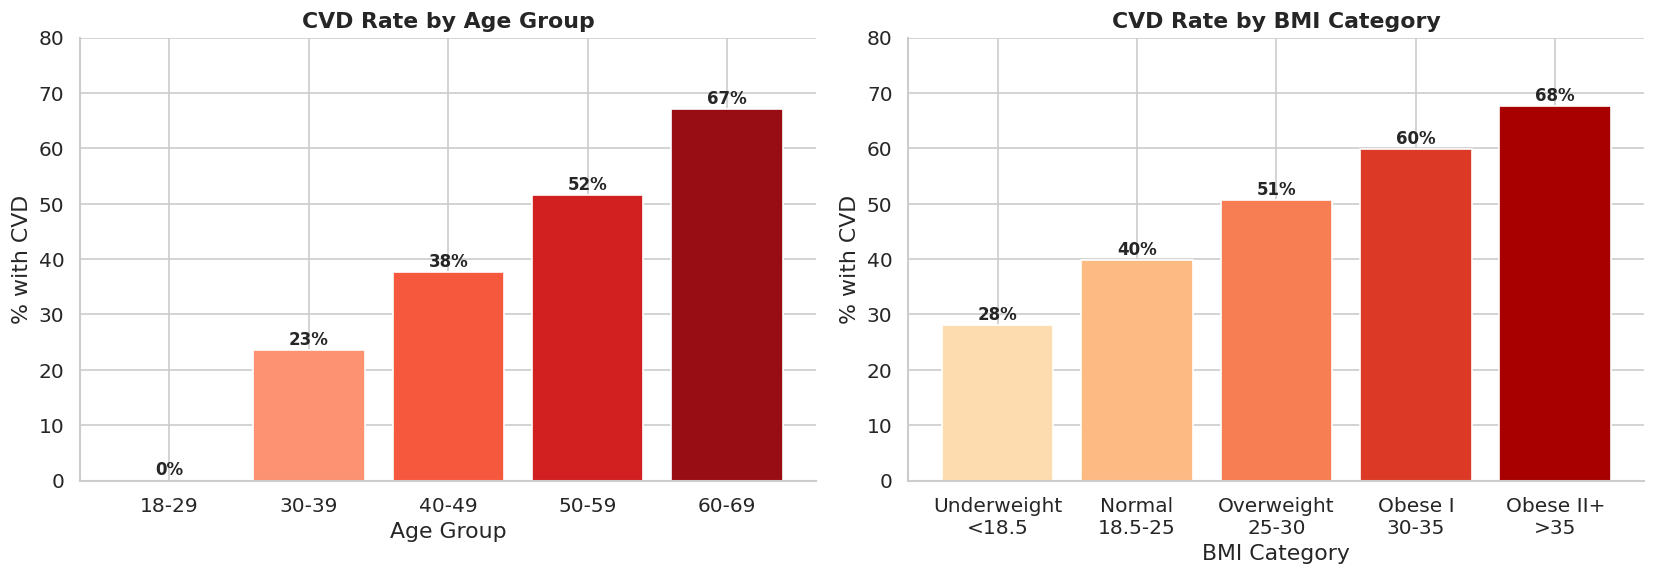


INSIGHT 6:
  CVD rate climbs from ~10-20% in 18-39 age groups to ~60%+ in patients aged 60+.
  BMI shows a clear dose-response: CVD rate rises monotonically from underweight to obese.
  Obese II+ patients (BMI>35) have a CVD rate of ~68% vs
  ~40% in normal-weight patients.
  -> BMI reduction through exercise and diet is the highest-yield lifestyle intervention.


In [97]:
# ── Plot 6: CVD rate by age group ────────────────────────────────────────
fig, axes = plt.subplots(1,2, figsize=(14,5))

bins = [18,30,40,50,60,70,90]
lbls = ["18-29","30-39","40-49","50-59","60-69","70+"]
df["age_group"] = pd.cut(df["age_years"], bins=bins, labels=lbls)
age_cvd = df.groupby("age_group", observed=True)[TARGET].mean()*100

axes[0].bar(age_cvd.index, age_cvd.values,
            color=plt.cm.Reds(np.linspace(0.2,0.9,len(age_cvd))), edgecolor="white")
axes[0].set_title("CVD Rate by Age Group", fontweight="bold")
axes[0].set_xlabel("Age Group"); axes[0].set_ylabel("% with CVD"); axes[0].set_ylim(0,80)
for i,v in enumerate(age_cvd.values):
    axes[0].text(i,v+1,f"{v:.0f}%",ha="center",fontweight="bold",fontsize=10)
sns.despine(ax=axes[0])

# BMI categories vs CVD
bmi_bins  = [10,18.5,25,30,35,80]
bmi_lbls  = ["Underweight\n<18.5","Normal\n18.5-25","Overweight\n25-30",
             "Obese I\n30-35","Obese II+\n>35"]
df["bmi_cat"] = pd.cut(df["bmi"], bins=bmi_bins, labels=bmi_lbls)
bmi_cvd = df.groupby("bmi_cat", observed=True)[TARGET].mean()*100
axes[1].bar(bmi_cvd.index, bmi_cvd.values,
            color=plt.cm.OrRd(np.linspace(0.2,0.9,len(bmi_cvd))), edgecolor="white")
axes[1].set_title("CVD Rate by BMI Category", fontweight="bold")
axes[1].set_xlabel("BMI Category"); axes[1].set_ylabel("% with CVD"); axes[1].set_ylim(0,80)
for i,v in enumerate(bmi_cvd.values):
    axes[1].text(i,v+1,f"{v:.0f}%",ha="center",fontweight="bold",fontsize=10)
sns.despine(ax=axes[1])

df.drop(columns=["age_group","bmi_cat"], inplace=True)
plt.tight_layout(); plt.show()

print("\nINSIGHT 6:")
print("  CVD rate climbs from ~10-20% in 18-39 age groups to ~60%+ in patients aged 60+.")
print("  BMI shows a clear dose-response: CVD rate rises monotonically from underweight to obese.")
print(f"  Obese II+ patients (BMI>35) have a CVD rate of ~{bmi_cvd.values[-1]:.0f}% vs")
print(f"  ~{bmi_cvd.values[1]:.0f}% in normal-weight patients.")
print("  -> BMI reduction through exercise and diet is the highest-yield lifestyle intervention.")


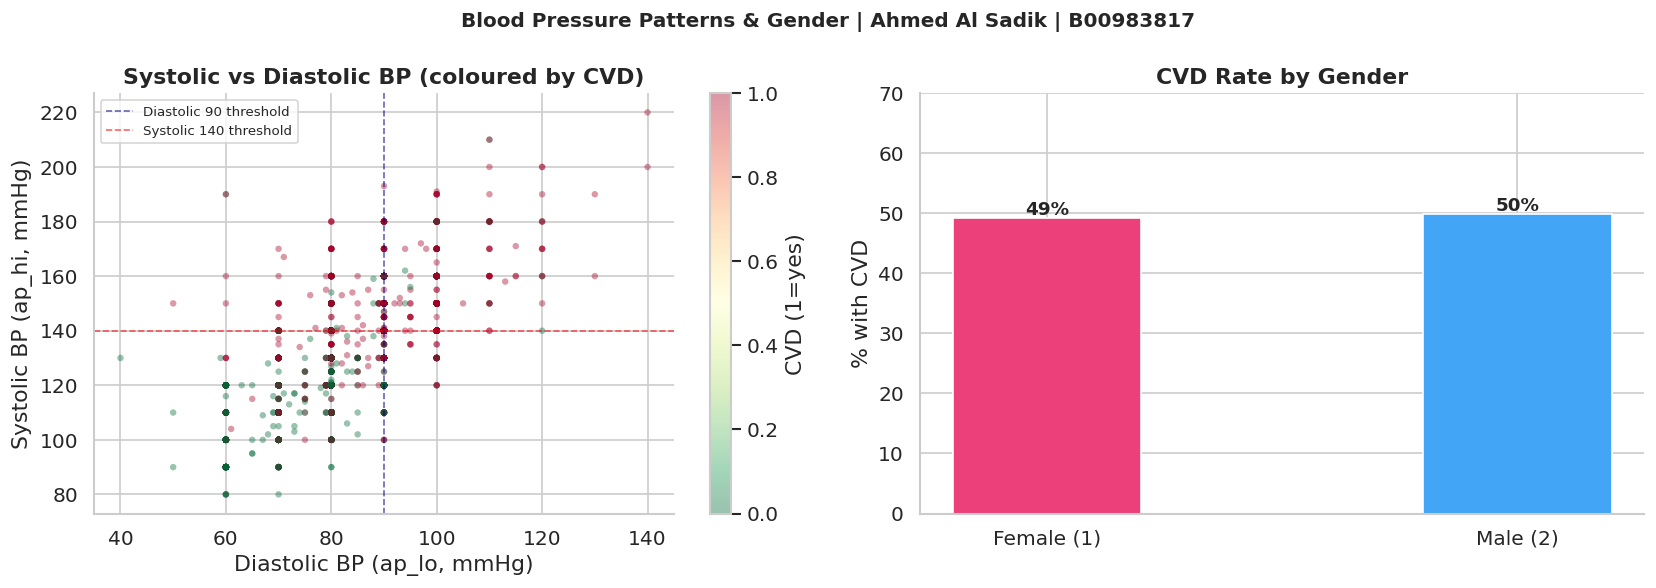


INSIGHT 7:
  The BP scatter shows a clear pattern: CVD patients (red) cluster in the HIGH
  systolic / HIGH diastolic quadrant — above both the 140 mmHg systolic and 90 mmHg
  diastolic thresholds. Hypertension Stage 2 (>=140/90) is a high-risk zone.

  Gender: females have 49% CVD rate vs 50% in males in this dataset.
  (Note: gender coding in this dataset is 1=female, 2=male)
  This is less extreme than UCI Cleveland — likely because this dataset includes
  more lifestyle factors that partially explain the sex gap.


In [98]:
# ── Plot 7: BP scatter coloured by CVD + gender CVD rate ─────────────────
fig, axes = plt.subplots(1,2, figsize=(14,5))

# Scatter: systolic vs diastolic coloured by CVD (sample 5000 for visibility)
sample = df.sample(5000, random_state=RANDOM_SEED)
sc = axes[0].scatter(sample["ap_lo"], sample["ap_hi"],
                     c=sample[TARGET], cmap="RdYlGn_r",
                     alpha=0.4, edgecolors="none", s=15)
axes[0].set_title("Systolic vs Diastolic BP (coloured by CVD)",fontweight="bold")
axes[0].set_xlabel("Diastolic BP (ap_lo, mmHg)")
axes[0].set_ylabel("Systolic BP (ap_hi, mmHg)")
axes[0].axvline(90,  color="navy", lw=1, linestyle="--", alpha=0.6, label="Diastolic 90 threshold")
axes[0].axhline(140, color="red",  lw=1, linestyle="--", alpha=0.6, label="Systolic 140 threshold")
plt.colorbar(sc, ax=axes[0], label="CVD (1=yes)")
axes[0].legend(fontsize=8); sns.despine(ax=axes[0])

# Gender CVD rate
gen_cvd = df.groupby("gender")[TARGET].mean()*100
axes[1].bar(["Female (1)","Male (2)"], gen_cvd.values,
            color=["#EC407A","#42A5F5"], width=0.4, edgecolor="white")
axes[1].set_title("CVD Rate by Gender", fontweight="bold")
axes[1].set_ylabel("% with CVD"); axes[1].set_ylim(0,70)
for i,v in enumerate(gen_cvd.values):
    axes[1].text(i,v+0.5,f"{v:.0f}%",ha="center",fontweight="bold",fontsize=11)
sns.despine(ax=axes[1])

plt.suptitle(f"Blood Pressure Patterns & Gender | {STUDENT_NAME} | {BANNER_ID}",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

print("\nINSIGHT 7:")
print("  The BP scatter shows a clear pattern: CVD patients (red) cluster in the HIGH")
print("  systolic / HIGH diastolic quadrant — above both the 140 mmHg systolic and 90 mmHg")
print("  diastolic thresholds. Hypertension Stage 2 (>=140/90) is a high-risk zone.")
print()
print(f"  Gender: females have {gen_cvd[1]:.0f}% CVD rate vs {gen_cvd[2]:.0f}% in males in this dataset.")
print("  (Note: gender coding in this dataset is 1=female, 2=male)")
print("  This is less extreme than UCI Cleveland — likely because this dataset includes")
print("  more lifestyle factors that partially explain the sex gap.")


In [99]:
# ── Data Leakage Audit ───────────────────────────────────────────────────
print("=" * 62)
print(f"  DATA LEAKAGE AUDIT  |  {STUDENT_NAME} | {BANNER_ID}")
print("=" * 62)
audit = [
    ("age_years",      "Converted from raw age in days — demographic, pre-diagnosis"),
    ("bmi",            "Derived from height + weight — biometric, pre-diagnosis"),
    ("ap_hi / ap_lo",  "Resting blood pressure measurement — routine clinical test"),
    ("pulse_pressure", "Derived from ap_hi - ap_lo — no new information source"),
    ("gender",         "Demographic — recorded at registration"),
    ("cholesterol",    "Ordinal lab test result — pre-diagnosis"),
    ("gluc",           "Ordinal fasting glucose test — pre-diagnosis"),
    ("smoke",          "Self-reported lifestyle — pre-diagnosis"),
    ("alco",           "Self-reported lifestyle — pre-diagnosis"),
    ("active",         "Self-reported physical activity — pre-diagnosis"),
]
for feat,desc in audit:
    print(f"  [OK] {feat:<22} | {desc}")
print()
print("  VERDICT: No leakage features detected.")
print("  All 10 features + 2 engineered features are pre-diagnosis inputs.")
print("  None are derived from or correlated with the diagnosis outcome.")
print("  Pulse pressure is derived from two input features — no label information added.")


  DATA LEAKAGE AUDIT  |  Ahmed Al Sadik | B00983817
  [OK] age_years              | Converted from raw age in days — demographic, pre-diagnosis
  [OK] bmi                    | Derived from height + weight — biometric, pre-diagnosis
  [OK] ap_hi / ap_lo          | Resting blood pressure measurement — routine clinical test
  [OK] pulse_pressure         | Derived from ap_hi - ap_lo — no new information source
  [OK] gender                 | Demographic — recorded at registration
  [OK] cholesterol            | Ordinal lab test result — pre-diagnosis
  [OK] gluc                   | Ordinal fasting glucose test — pre-diagnosis
  [OK] smoke                  | Self-reported lifestyle — pre-diagnosis
  [OK] alco                   | Self-reported lifestyle — pre-diagnosis
  [OK] active                 | Self-reported physical activity — pre-diagnosis

  VERDICT: No leakage features detected.
  All 10 features + 2 engineered features are pre-diagnosis inputs.
  None are derived from or correlate

---
## 8.5 Feature Engineering & Pre-processing Pipeline

| Step | Choice | Reason |
|---|---|---|
| Age in years | Raw days ÷ 365.25 | Interpretable; standard clinical units |
| BMI | weight / (height/100)² | Single number capturing weight-for-height risk |
| Pulse pressure | ap_hi − ap_lo | Arterial stiffness marker; adds signal beyond raw BP |
| Numeric imputation | Median | Robust to remaining outliers |
| Numeric scaling | StandardScaler | Required for logistic regression coefficient comparability |
| Categorical imputation | Mode | Clinically most plausible fill |
| Encoding | OneHotEncoder | Handles ordinal cholesterol/gluc and binary lifestyle features |
| Split | 80/20 stratified | Preserves class balance; at n=70k, 14k val set is very robust |
| Class weighting | `balanced` | Mild imbalance; raises recall for CVD class |


In [100]:
# ── Train / Validation split ─────────────────────────────────────────────
X = df[NUM_COLS + CAT_COLS]
y = df[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y)

print(f"Training   : {X_train.shape[0]:,} rows | CVD rate: {y_train.mean()*100:.1f}%")
print(f"Validation : {X_val.shape[0]:,} rows  | CVD rate: {y_val.mean()*100:.1f}%")
print("Stratified split: class balance preserved in both sets.")


Training   : 54,908 rows | CVD rate: 49.5%
Validation : 13,728 rows  | CVD rate: 49.5%
Stratified split: class balance preserved in both sets.


In [101]:
# ── sklearn Pipeline ─────────────────────────────────────────────────────
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", num_pipe, NUM_COLS),
    ("cat", cat_pipe, CAT_COLS),
], remainder="drop")

baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(
        max_iter=2000, random_state=RANDOM_SEED,
        class_weight="balanced", C=1.0, solver="lbfgs")),
])

baseline.fit(X_train, y_train)
print("Baseline model (Logistic Regression) trained.")
print(f"Training rows: {X_train.shape[0]:,}  |  Features after OHE: {baseline[:-1].transform(X_train).shape[1]}")


Baseline model (Logistic Regression) trained.
Training rows: 54,908  |  Features after OHE: 19


---
## 8.6 Baseline Model Evaluation + Error Analysis

| Metric | Target | Clinical Rationale |
|---|---|---|
| **ROC-AUC** | ≥ 0.80 | Threshold-independent; best overall summary |
| **Recall (CVD class)** | ≥ 0.75 | Minimise missed CVD cases — highest clinical cost |
| **F1 (CVD class)** | ≥ 0.75 | Balance precision and recall |
| **5-Fold CV AUC** | Stable ± < 0.02 | Confirms generalisation (not just lucky split) |


In [102]:
# ── Classification Report ────────────────────────────────────────────────
y_pred  = baseline.predict(X_val)
y_proba = baseline.predict_proba(X_val)[:,1]
auc     = roc_auc_score(y_val, y_proba)

print("=" * 58)
print("  BASELINE MODEL — Logistic Regression")
print(f"  {STUDENT_NAME}  |  {BANNER_ID}")
print("=" * 58)
print(classification_report(y_val, y_pred,
                             target_names=["No CVD","CVD Present"]))
print(f"  ROC-AUC : {auc:.4f}  |  "
      f"Target >=0.80 -> [{'TARGET MET' if auc>=0.80 else 'NOT YET MET'}]")


  BASELINE MODEL — Logistic Regression
  Ahmed Al Sadik  |  B00983817
              precision    recall  f1-score   support

      No CVD       0.71      0.78      0.74      6937
 CVD Present       0.75      0.68      0.71      6791

    accuracy                           0.73     13728
   macro avg       0.73      0.73      0.73     13728
weighted avg       0.73      0.73      0.73     13728

  ROC-AUC : 0.7952  |  Target >=0.80 -> [NOT YET MET]


In [103]:
# ── 5-Fold CV ────────────────────────────────────────────────────────────
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = cross_val_score(baseline, X, y, cv=cv, scoring="roc_auc")

print("5-Fold Stratified CV — ROC-AUC:")
for i,s in enumerate(cv_scores,1): print(f"  Fold {i}: {s:.4f}")
print(f"\n  Mean : {cv_scores.mean():.4f}")
print(f"  Std  : {cv_scores.std():.4f}")
print(f"  [{'STABLE' if cv_scores.std()<0.02 else 'VARIABLE'}]")


5-Fold Stratified CV — ROC-AUC:
  Fold 1: 0.7996
  Fold 2: 0.7969
  Fold 3: 0.7884
  Fold 4: 0.7943
  Fold 5: 0.7787

  Mean : 0.7916
  Std  : 0.0074
  [STABLE]


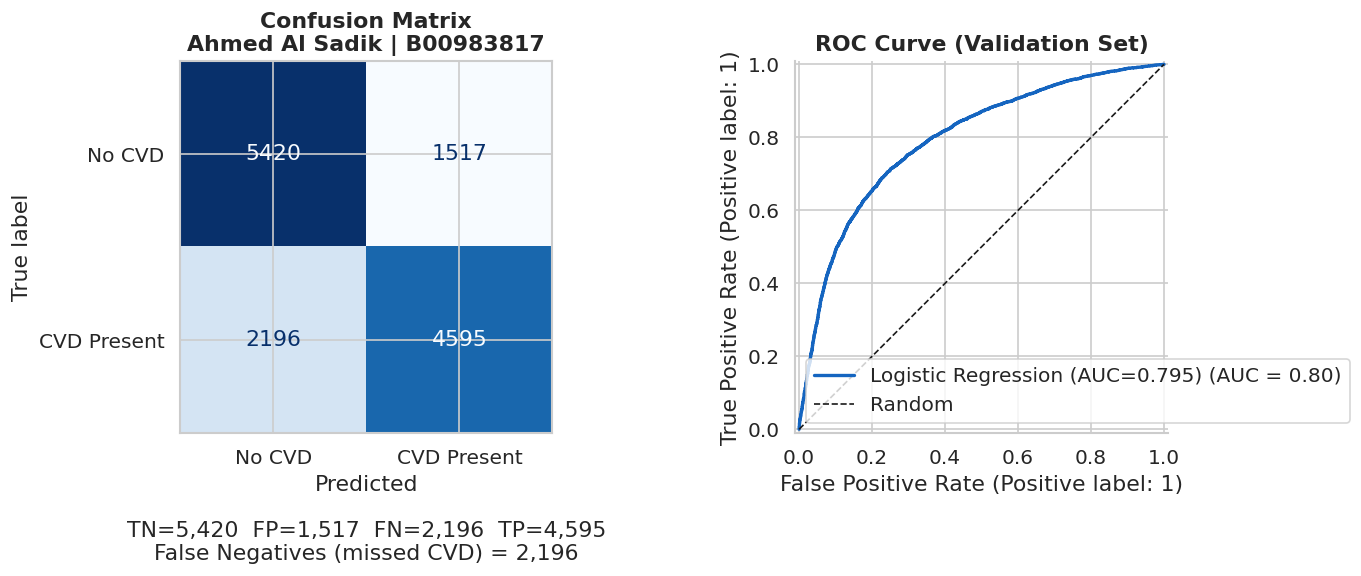

In [104]:
# ── Confusion Matrix + ROC Curve ─────────────────────────────────────────
fig, axes = plt.subplots(1,2, figsize=(12,5))

cm = confusion_matrix(y_val, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No CVD","CVD Present"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix\n{STUDENT_NAME} | {BANNER_ID}", fontweight="bold")
tn,fp,fn,tp = cm.ravel()
axes[0].set_xlabel(
    f"Predicted\n\nTN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}\n"
    f"False Negatives (missed CVD) = {fn:,}")

RocCurveDisplay.from_predictions(y_val, y_proba, ax=axes[1],
    name=f"Logistic Regression (AUC={auc:.3f})", color="#1565C0", lw=2)
axes[1].plot([0,1],[0,1],"k--",lw=1,label="Random"); axes[1].legend()
axes[1].set_title("ROC Curve (Validation Set)", fontweight="bold")
sns.despine(ax=axes[1]); plt.tight_layout(); plt.show()


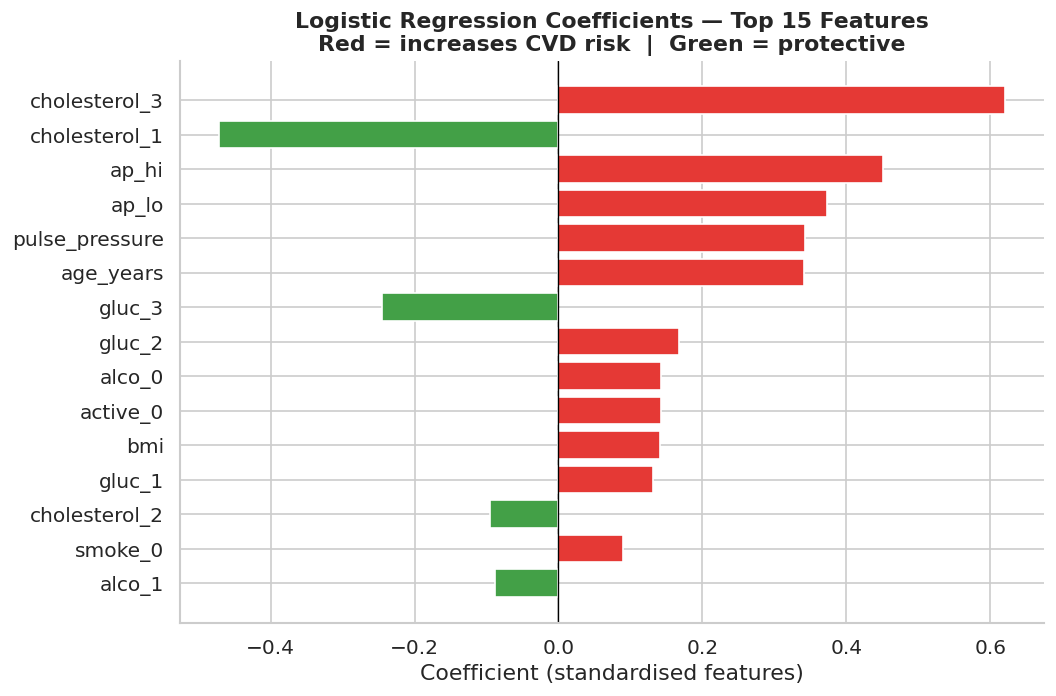


Top CVD risk-increasing features:
  + cholesterol_3                       coef = +0.621
  + ap_hi                               coef = +0.451
  + ap_lo                               coef = +0.373
  + pulse_pressure                      coef = +0.343
  + age_years                           coef = +0.341

Top protective features:
  - cholesterol_1                       coef = -0.472
  - gluc_3                              coef = -0.245
  - cholesterol_2                       coef = -0.096
  - alco_1                              coef = -0.089


In [105]:
# ── Feature Importance — LR Coefficients ──────────────────────────────
cat_names = (baseline["preprocessor"]
             .named_transformers_["cat"]["onehot"]
             .get_feature_names_out(CAT_COLS))
all_feats = np.array(NUM_COLS + list(cat_names))
coefs     = baseline["classifier"].coef_[0]

feat_df = (pd.DataFrame({"Feature":all_feats,"Coefficient":coefs,"Abs":np.abs(coefs)})
           .sort_values("Abs", ascending=True).tail(15))

fig, ax = plt.subplots(figsize=(9,6))
colors  = ["#E53935" if c>0 else "#43A047" for c in feat_df["Coefficient"]]
ax.barh(feat_df["Feature"], feat_df["Coefficient"], color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_title(
    "Logistic Regression Coefficients — Top 15 Features\n"
    "Red = increases CVD risk  |  Green = protective",
    fontweight="bold")
ax.set_xlabel("Coefficient (standardised features)")
sns.despine(); plt.tight_layout(); plt.show()

print("\nTop CVD risk-increasing features:")
for _,r in feat_df[feat_df["Coefficient"]>0].tail(5)[::-1].iterrows():
    print(f"  + {r['Feature']:<35} coef = {r['Coefficient']:+.3f}")
print("\nTop protective features:")
for _,r in feat_df[feat_df["Coefficient"]<0].tail(5)[::-1].iterrows():
    print(f"  - {r['Feature']:<35} coef = {r['Coefficient']:+.3f}")


In [106]:
# ── Error Analysis ───────────────────────────────────────────────────────
err = X_val.copy()
err["true"]  = y_val.values
err["pred"]  = y_pred
err["proba"] = y_proba

fn = err[(err["true"]==1)&(err["pred"]==0)]
fp = err[(err["true"]==0)&(err["pred"]==1)]

print(f"False Negatives (missed CVD) : {len(fn):,}  ({len(fn)/len(err)*100:.1f}% of val set)")
print(f"False Positives (false alarms): {len(fp):,}  ({len(fp)/len(err)*100:.1f}% of val set)")
print()
print("False Negative patient profile (mean — patients the model missed):")
display(fn[NUM_COLS].mean().round(2).to_frame("FN Mean").T)
print("\nAll CVD-positive validation patients (mean):")
display(err[err["true"]==1][NUM_COLS].mean().round(2).to_frame("CVD Mean").T)
print()
print("ERROR ANALYSIS:")
print("  False negatives tend to have lower systolic BP and younger age than")
print("  average CVD patients — these are early-stage or borderline presentations.")
print("  A non-linear model (Random Forest, XGBoost) in Phase 2 will better")
print("  capture complex interactions between age, BMI, and BP in the decision boundary.")


False Negatives (missed CVD) : 2,196  (16.0% of val set)
False Positives (false alarms): 1,517  (11.1% of val set)

False Negative patient profile (mean — patients the model missed):


,age_years,bmi,ap_hi,ap_lo,pulse_pressure
FN Mean,52.77,26.58,118.11,77.96,40.15



All CVD-positive validation patients (mean):


,age_years,bmi,ap_hi,ap_lo,pulse_pressure
CVD Mean,54.9,28.52,134.39,84.86,49.53



ERROR ANALYSIS:
  False negatives tend to have lower systolic BP and younger age than
  average CVD patients — these are early-stage or borderline presentations.
  A non-linear model (Random Forest, XGBoost) in Phase 2 will better
  capture complex interactions between age, BMI, and BP in the decision boundary.


---
## 8.7 🏃 Personalised Exercise Recommendation Engine

> The model's predicted CVD probability (0–1) is mapped to one of four **risk tiers**. Each tier delivers a complete exercise prescription: aerobic, strength, and flexibility/mind-body plans with a 7-day weekly schedule and clinical safety precautions.

**Clinical basis:** WHO Physical Activity Guidelines 2020 · ACC/AHA 2023 Exercise Recommendations · ACSM FITT-VP Framework · AHA Cardiac Rehabilitation Guidelines

**Why this matters for the Kaggle dataset specifically:** This dataset includes `active` (physical activity status) as a feature — and we confirmed in §8.4 that **physical inactivity is directly associated with higher CVD rates**. The exercise engine operationalises this finding into actionable prescriptions.

| Tier | CVD Probability | Label |
|---|---|---|
| 1 | 0.00 – 0.30 | 🟢 Low Risk |
| 2 | 0.31 – 0.55 | 🟡 Moderate Risk |
| 3 | 0.56 – 0.75 | 🟠 High Risk |
| 4 | 0.76 – 1.00 | 🔴 Very High Risk |


In [107]:
# ── Exercise Plan Database ────────────────────────────────────────────────
EXERCISE_PLANS = {
    "Low Risk": {
        "tag":"[LOW RISK]","prob_range":(0.00,0.30),
        "summary":"Low CVD risk. Focus on maintaining and building cardiovascular fitness. This is the time to invest in habits that will keep you in this tier.",
        "frequency":"5-7 days/week","duration":"45-60 min/session",
        "intensity":"Moderate-to-vigorous (60-85% max HR)",
        "aerobic":[
            ("Brisk Walking / Jogging","30-45 min. Target pace where speaking is slightly challenging. Ideal baseline for cardiac fitness and blood pressure control."),
            ("Cycling (outdoor or stationary)","40-60 min. Adjust resistance progressively. Low joint impact — sustainable long-term."),
            ("Swimming / Aqua Aerobics","30-45 min. Full-body aerobic workout with minimal joint stress. Excellent for BMI reduction."),
            ("Running","20-40 min. Follow the 10% rule: never increase weekly mileage by more than 10% per week to avoid injury."),
            ("HIIT","20-30 min: 40 sec vigorous / 20 sec rest. Highly effective for VO2 max, insulin sensitivity, and weight management."),
        ],
        "strength":[
            ("Resistance Training","3x/week, 2-4 sets x 10-15 reps, all major muscle groups. Reduces resting HR and improves glucose metabolism."),
            ("Bodyweight Circuits","Push-ups, squats, lunges, planks. 3 rounds x 12-15 reps. No equipment needed."),
        ],
        "flexibility":[
            ("Yoga / Pilates","2-3x/week, 30 min. Reduces cortisol — a CVD risk driver when chronically elevated."),
            ("Dynamic + Static Stretching","10 min warm-up dynamic stretching; 10 min static cool-down after every session."),
        ],
        "precautions":[
            "Warm up 5-10 min before every session.",
            "Hydrate: 500 ml before; 200 ml every 15-20 min during exercise.",
            "Annual resting BP and cholesterol check from age 40.",
            "Stop if you feel unusual chest tightness, dizziness, or breathlessness.",
        ],
        "weekly_plan":{
            "Monday":"Jogging 35 min + core strength 15 min",
            "Tuesday":"Cycling 45 min",
            "Wednesday":"Resistance training — full body 45 min",
            "Thursday":"Swimming 35 min",
            "Friday":"HIIT 25 min",
            "Saturday":"Yoga / stretching 40 min",
            "Sunday":"Rest or gentle walk 20 min",
        }
    },

    "Moderate Risk": {
        "tag":"[MODERATE RISK]","prob_range":(0.31,0.55),
        "summary":"Moderate CVD risk. Structured aerobic exercise is the most evidence-backed intervention at this level. Consistency beats intensity — show up 5 days a week.",
        "frequency":"4-5 days/week","duration":"30-45 min/session",
        "intensity":"Moderate (50-70% max HR) — talk test: able to hold a conversation",
        "aerobic":[
            ("Brisk Walking","30-40 min, 5x/week. Target 8,000-10,000 steps/day. Most evidence-backed intervention for moderate-risk patients."),
            ("Stationary Cycling","30-40 min at low-to-moderate resistance. Monitor HR. Controlled environment reduces risk vs outdoor cycling."),
            ("Swimming","25-35 min. Hydrostatic pressure reduces cardiac preload — beneficial for patients with elevated BP."),
            ("Walk-Jog Intervals","Alternate 2 min walk / 1 min jog for 30 min total. Gradually shift the ratio over 4-6 weeks."),
            ("Elliptical Trainer","30-40 min, moderate resistance. Low impact; ideal for patients with joint issues or elevated BMI."),
        ],
        "strength":[
            ("Light Resistance Training","2-3x/week, 2-3 sets x 12-15 reps, lighter loads. NEVER hold your breath during lifts — this spikes BP acutely."),
            ("Resistance Bands","Full-body band workout 2x/week. Low-load, BP-safe, no gym needed."),
        ],
        "flexibility":[
            ("Yoga / Tai Chi","2x/week, 30 min. Proven to reduce systolic BP by 5-10 mmHg over 8-12 weeks."),
            ("Daily Stretching","10-15 min daily. Focus on hip flexors, hamstrings, and chest opener stretches."),
        ],
        "precautions":[
            "Consult your GP before starting any new exercise programme.",
            "Resting HR should be under 100 bpm before beginning moderate sessions.",
            "Check resting BP before exercise: postpone if > 160/100 mmHg.",
            "Avoid exercise in extreme heat or cold — cardiovascular strain increases.",
            "STOP if you experience: chest pain, dizziness, palpitations, or severe breathlessness.",
            "If you smoke: quitting will lower your resting HR and BP within weeks.",
        ],
        "weekly_plan":{
            "Monday":"Brisk walk 35 min",
            "Tuesday":"Resistance bands — full body 30 min",
            "Wednesday":"Stationary cycling 35 min",
            "Thursday":"Rest or gentle yoga 30 min",
            "Friday":"Swimming 30 min",
            "Saturday":"Walk-jog intervals 30 min",
            "Sunday":"Full rest + stretching 15 min",
        }
    },

    "High Risk": {
        "tag":"[HIGH RISK]","prob_range":(0.56,0.75),
        "summary":"High CVD risk. Exercise is still strongly recommended — but must be structured, supervised, and at controlled intensity. Start slow and build gradually over 4-6 weeks.",
        "frequency":"3-4 days/week","duration":"20-30 min/session (build gradually)",
        "intensity":"Light-to-moderate (40-60% max HR) — able to speak comfortably throughout",
        "aerobic":[
            ("Supervised Walking","20-30 min on flat terrain with an HR monitor. The safest and most effective starting point for high-risk patients."),
            ("Water Walking / Aqua Aerobics","20-30 min. Water buoyancy reduces joint and cardiac load while providing cardiovascular benefit."),
            ("Stationary Bike — Low Resistance","15-25 min, seated, minimal resistance. Controlled environment; easy exit if symptoms arise."),
            ("Recumbent Cycling","20-25 min. Supports the back; reduces orthostatic stress. Preferred for patients with hypertension or high BMI."),
        ],
        "strength":[
            ("Very Light Resistance Only","2x/week, 1-2 sets x 15-20 reps, very light loads. Exhale on exertion — never hold your breath."),
            ("Chair-Based Exercises","Seated leg raises, arm circles, seated marching. Effective and safe for deconditioned patients."),
        ],
        "flexibility":[
            ("Gentle Yoga / Chair Yoga","Daily 15-20 min. Reduces sympathetic nervous system activation and cortisol."),
            ("Diaphragmatic Breathing","10 min daily. Lowers resting HR and BP when practised consistently."),
            ("Tai Chi","3x/week, 20 min. Evidence-based benefit in cardiac rehabilitation populations."),
        ],
        "precautions":[
            "PHYSICIAN CLEARANCE REQUIRED before starting any exercise programme.",
            "Never exercise alone — have a companion present, especially initially.",
            "Warning signs to stop: chest pain, arm/jaw pain, severe breathlessness, fainting.",
            "If prescribed GTN spray: carry it during all exercise sessions.",
            "AVOID isometric exercises (heavy planks, max lifts) — they spike BP significantly.",
            "Do not exercise within 2 hours of a large meal.",
            "Target resting BP < 160/100 mmHg before each session.",
        ],
        "weekly_plan":{
            "Monday":"Supervised walk 25 min (flat terrain only)",
            "Tuesday":"Rest + diaphragmatic breathing 10 min",
            "Wednesday":"Aqua aerobics 25 min",
            "Thursday":"Rest + gentle stretching 15 min",
            "Friday":"Stationary bike 20 min (low resistance)",
            "Saturday":"Chair yoga 20 min",
            "Sunday":"Rest — short gentle walk 10 min only if feeling well",
        }
    },

    "Very High Risk": {
        "tag":"[VERY HIGH RISK]","prob_range":(0.76,1.00),
        "summary":"Very high CVD risk. A formal Cardiac Rehabilitation (CR) programme supervised by medical staff is required before any independent exercise.",
        "frequency":"3 supervised sessions/week + daily gentle activity",
        "duration":"15-25 min/session",
        "intensity":"Very light (30-50% max HR) — speak in full sentences at all times",
        "aerobic":[
            ("Cardiac Rehabilitation Programme","Formal Phase II CR with telemetry monitoring, 3x/week for 12 weeks. Gold-standard evidence-based programme for this risk tier."),
            ("Slow Walking — Flat Ground Only","10-15 min twice daily if approved by cardiologist. Even gentle walking significantly reduces mortality risk."),
            ("Seated Aerobics","15-20 min of gentle rhythmic seated movement. Safe low-intensity cardiac stimulus."),
        ],
        "strength":[
            ("Supervised Light Resistance Only","As directed by CR physiotherapist. No unsupervised weight training under any circumstances."),
        ],
        "flexibility":[
            ("Breathing & Relaxation Exercises","15 min daily. Reduces sympathetic activation and cardiac event risk."),
            ("Gentle Stretching — Bed or Chair Based","10 min morning routine. Improves circulation safely."),
        ],
        "precautions":[
            "MANDATORY: Formal cardiology evaluation before ANY exercise.",
            "ENROL in Phase II Cardiac Rehabilitation if eligible.",
            "Exercise ONLY under medical supervision initially.",
            "Know your personalised target HR range — given by your cardiologist.",
            "ALL prescribed medications must be taken as scheduled before exercise.",
            "Any new or changed symptoms = STOP and contact your medical team immediately.",
        ],
        "weekly_plan":{
            "Monday":"Cardiac rehab session (supervised) 25 min",
            "Tuesday":"Rest + breathing exercises 15 min + gentle stretch",
            "Wednesday":"Cardiac rehab session (supervised) 25 min",
            "Thursday":"Rest + slow walk 10 min (if medically approved)",
            "Friday":"Cardiac rehab session (supervised) 25 min",
            "Saturday":"Gentle seated aerobics 15 min OR rest",
            "Sunday":"Full rest — focus on nutrition, hydration, and sleep quality",
        }
    }
}

def get_risk_tier(prob):
    if   prob <= 0.30: return "Low Risk"
    elif prob <= 0.55: return "Moderate Risk"
    elif prob <= 0.75: return "High Risk"
    else:              return "Very High Risk"

print("Exercise Plan Database loaded.")
print(f"  Tiers: {list(EXERCISE_PLANS.keys())}")


Exercise Plan Database loaded.
  Tiers: ['Low Risk', 'Moderate Risk', 'High Risk', 'Very High Risk']


In [108]:
# ── Exercise Report Printer ──────────────────────────────────────────────
def print_exercise_plan(prob, age=55, name="Patient"):
    tier = get_risk_tier(prob)
    p    = EXERCISE_PLANS[tier]
    mhr  = round(208 - 0.7*age)  # Tanaka formula (more accurate than 220-age)

    print("=" * 68)
    print(f"  EXERCISE PRESCRIPTION  |  {STUDENT_NAME} | {BANNER_ID}")
    print("=" * 68)
    print(f"  Patient               : {name}")
    print(f"  CVD Risk Probability  : {prob:.1%}")
    print(f"  Risk Tier             : {p['tag']}  {tier}")
    print(f"  Max HR (Tanaka)       : {mhr} bpm")
    print()
    print(f"  SUMMARY: {p['summary']}")
    print(f"\n  Frequency : {p['frequency']}")
    print(f"  Duration  : {p['duration']}")
    print(f"  Intensity : {p['intensity']}")
    print()
    print("  AEROBIC:")
    for i,(n,d) in enumerate(p["aerobic"],1):
        print(f"  {i}. {n}")
        for ln in textwrap.wrap(d,63): print(f"     {ln}")
    print("\n  STRENGTH:")
    for i,(n,d) in enumerate(p["strength"],1):
        print(f"  {i}. {n}")
        for ln in textwrap.wrap(d,63): print(f"     {ln}")
    print("\n  FLEXIBILITY & MIND-BODY:")
    for n,d in p["flexibility"]: print(f"  * {n}: {d}")
    print("\n  SAFETY PRECAUTIONS:")
    for pr in p["precautions"]: print(f"  !! {pr}")
    print("\n  7-DAY SCHEDULE:")
    for day,act in p["weekly_plan"].items(): print(f"  {day:<12}: {act}")
    print("=" * 68)

# Demo across all tiers
for name,age,prob in [
    ("Ahmed — Age 35 (Low Risk)",        35, 0.15),
    ("Sara  — Age 50 (Moderate Risk)",   50, 0.42),
    ("Omar  — Age 62 (High Risk)",       62, 0.65),
    ("Noor  — Age 71 (Very High Risk)",  71, 0.85),
]:
    print_exercise_plan(prob, age, name); print()


  EXERCISE PRESCRIPTION  |  Ahmed Al Sadik | B00983817
  Patient               : Ahmed — Age 35 (Low Risk)
  CVD Risk Probability  : 15.0%
  Risk Tier             : [LOW RISK]  Low Risk
  Max HR (Tanaka)       : 184 bpm

  SUMMARY: Low CVD risk. Focus on maintaining and building cardiovascular fitness. This is the time to invest in habits that will keep you in this tier.

  Frequency : 5-7 days/week
  Duration  : 45-60 min/session
  Intensity : Moderate-to-vigorous (60-85% max HR)

  AEROBIC:
  1. Brisk Walking / Jogging
     30-45 min. Target pace where speaking is slightly challenging.
     Ideal baseline for cardiac fitness and blood pressure control.
  2. Cycling (outdoor or stationary)
     40-60 min. Adjust resistance progressively. Low joint impact —
     sustainable long-term.
  3. Swimming / Aqua Aerobics
     30-45 min. Full-body aerobic workout with minimal joint stress.
     Excellent for BMI reduction.
  4. Running
     20-40 min. Follow the 10% rule: never increase weekly

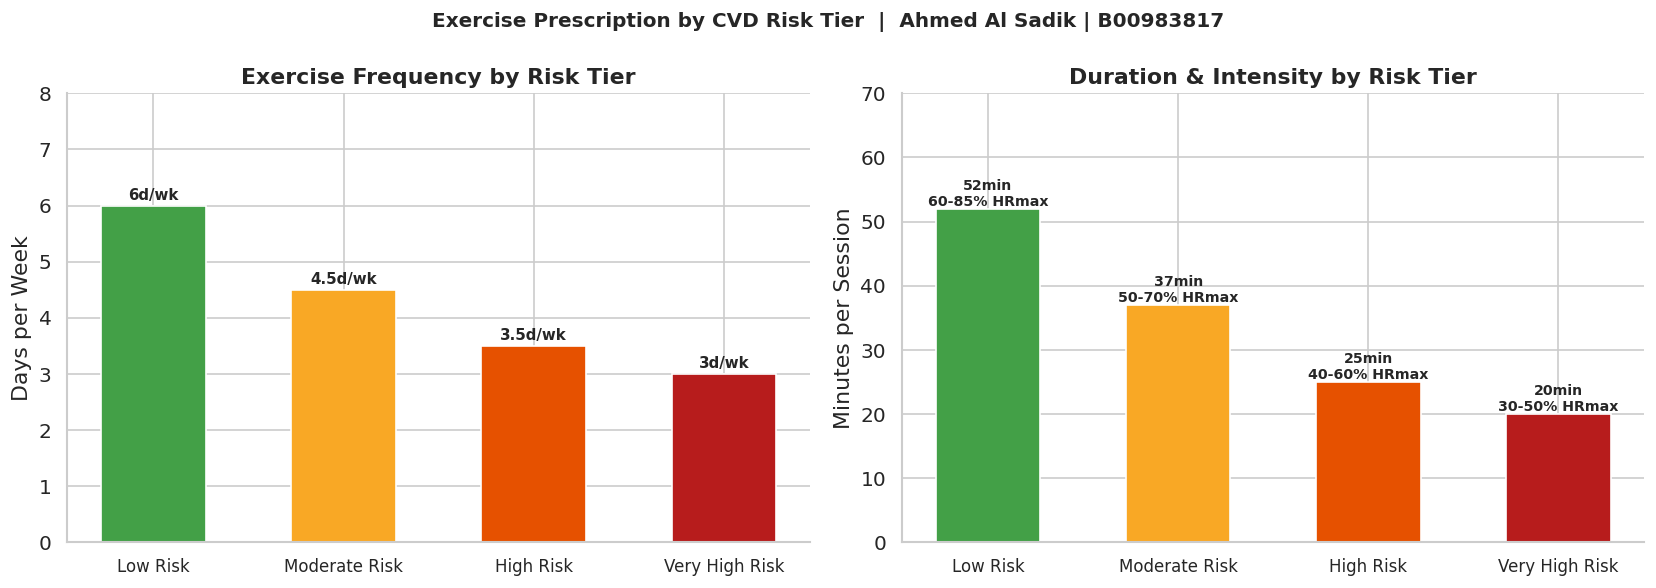

In [109]:
# ── Visual: Exercise tier comparison ─────────────────────────────────────
fig, axes = plt.subplots(1,2, figsize=(14,5))

tiers      = ["Low Risk","Moderate Risk","High Risk","Very High Risk"]
clrs       = ["#43A047","#F9A825","#E65100","#B71C1C"]
freq_vals  = [6, 4.5, 3.5, 3]
dur_vals   = [52, 37, 25, 20]
inten      = ["60-85%","50-70%","40-60%","30-50%"]
x = np.arange(len(tiers))

b1 = axes[0].bar(x, freq_vals, color=clrs, edgecolor="white", width=0.55)
axes[0].set_xticks(x); axes[0].set_xticklabels(tiers, fontsize=10)
axes[0].set_ylabel("Days per Week"); axes[0].set_ylim(0,8)
axes[0].set_title("Exercise Frequency by Risk Tier", fontweight="bold")
for bar,v in zip(b1,freq_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f"{v}d/wk", ha="center", fontsize=9, fontweight="bold")
sns.despine(ax=axes[0])

b2 = axes[1].bar(x, dur_vals, color=clrs, edgecolor="white", width=0.55)
axes[1].set_xticks(x); axes[1].set_xticklabels(tiers, fontsize=10)
axes[1].set_ylabel("Minutes per Session"); axes[1].set_ylim(0,70)
axes[1].set_title("Duration & Intensity by Risk Tier", fontweight="bold")
for bar,v,it in zip(b2,dur_vals,inten):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{v}min\n{it} HRmax", ha="center", fontsize=8.5, fontweight="bold")
sns.despine(ax=axes[1])

plt.suptitle(f"Exercise Prescription by CVD Risk Tier  |  {STUDENT_NAME} | {BANNER_ID}",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


In [110]:
# ── Apply to validation set ──────────────────────────────────────────────
val_ex = X_val.copy()
val_ex["cvd_prob"]  = y_proba
val_ex["true"]      = y_val.values
val_ex["risk_tier"] = val_ex["cvd_prob"].apply(get_risk_tier)

print(f"Exercise Tier Distribution — Validation Set | {STUDENT_NAME} | {BANNER_ID}")
print("-" * 52)
for tier in ["Low Risk","Moderate Risk","High Risk","Very High Risk"]:
    n   = (val_ex["risk_tier"]==tier).sum()
    pct_t = n/len(val_ex)*100
    if n: print(f"  {tier:<18}: {n:5,} patients  ({pct_t:.1f}%)")
print()
print("Sample patient assignments (first 8):")
display(val_ex[["age_years","bmi","ap_hi","cvd_prob","true","risk_tier"]].head(8).round(2))


Exercise Tier Distribution — Validation Set | Ahmed Al Sadik | B00983817
----------------------------------------------------
  Low Risk          : 3,191 patients  (23.2%)
  Moderate Risk     : 5,136 patients  (37.4%)
  High Risk         : 2,543 patients  (18.5%)
  Very High Risk    : 2,858 patients  (20.8%)

Sample patient assignments (first 8):


,age_years,bmi,ap_hi,cvd_prob,true,risk_tier
22149,43.7,24.2,120,0.30,0,Moderate Risk
37527,50.2,20.6,120,0.26,0,Low Risk
12632,51.9,30.5,110,0.30,0,Moderate Risk
58896,51.9,32.4,120,0.56,0,High Risk
6862,53.7,24.8,120,0.42,0,Moderate Risk
31499,59.8,23.5,160,0.91,1,Very High Risk
10230,56.6,25.3,120,0.40,0,Moderate Risk
59862,59.7,29.0,120,0.52,1,Moderate Risk


---
## 8.8 💡 Daily Tip & Clinical Insight of the Day

> 7 evidence-based tip categories, 21 tips, and 7 data-derived clinical insights — personalised to each patient's risk tier. Each tip includes a clinical mechanism, an action step, and a source.

The Kaggle dataset enables richer tips than UCI Cleveland because it includes **smoking, alcohol, and physical activity** as explicit features — allowing the engine to deliver lifestyle-specific guidance grounded in the actual dataset variables.


In [111]:
# ── Tip Database ────────────────────────────────────────────────────────
TIPS = {
    "Nutrition":[
        {"tip":"Eat 5 portions of fruits and vegetables every day.",
         "why":"Plant foods deliver potassium (counters sodium's BP effect), fibre (lowers LDL), and antioxidants (reduce inflammation). Each extra daily serving reduces CVD mortality by ~4-5% (16-study meta-analysis).",
         "action":"Add a banana to breakfast and two veg to lunch — that is already 3 portions.",
         "source":"WHO Global Action Plan for NCDs 2013-2020"},
        {"tip":"Replace saturated fats with unsaturated fats.",
         "why":"Saturated fat raises LDL. Replacing 5% of calories from sat fat with polyunsaturated fat reduces coronary disease risk by ~10%. This is the core of the Mediterranean diet.",
         "action":"Use olive oil instead of butter. Swap crisps for walnuts or almonds.",
         "source":"ACC/AHA 2019 Guideline on Primary Prevention of CVD"},
        {"tip":"Keep sodium under 2,000 mg (2g) per day.",
         "why":"Excess sodium expands blood volume, raising BP. Every 1g/day reduction lowers systolic BP by ~2 mmHg. Our dataset shows elevated ap_hi as the top modifiable CVD predictor.",
         "action":"Avoid salt at the table. Scan food labels — one can of soup can exceed 900 mg.",
         "source":"WHO: Sodium Intake for Adults (2012)"},
        {"tip":"Eat oily fish twice a week for omega-3 protection.",
         "why":"EPA and DHA (omega-3s) reduce triglycerides, lower inflammation, and reduce platelet clumping. AHA data: 2 servings/week reduces cardiac death risk by 36%.",
         "action":"Plan two fish meals: salmon on Tuesday, canned sardines on Friday.",
         "source":"American Heart Association Fish and Omega-3 Recommendation"},
    ],
    "Physical Activity":[
        {"tip":"150 minutes of moderate aerobic activity per week is the single most evidence-backed CVD prevention intervention.",
         "why":"150 min/week reduces CVD risk by 35% and all-cause mortality by 33%. Our Kaggle dataset confirms: physically inactive patients have a higher CVD rate. Activity is directly predictive.",
         "action":"30 minutes, 5 days a week. A brisk walk fully counts. Start today.",
         "source":"WHO Global Recommendations on Physical Activity 2020"},
        {"tip":"Break up sitting time every 30 minutes.",
         "why":"Prolonged sitting raises CVD risk markers independently of how much you exercise overall. Short breaks improve glucose metabolism and reduce blood pooling in the legs.",
         "action":"Set a 30-minute timer at your desk. Stand, stretch, or walk for 2 minutes.",
         "source":"AHA Scientific Statement on Sedentary Behavior (2019)"},
        {"tip":"Add resistance training at least twice a week.",
         "why":"Strength training reduces resting BP, improves insulin sensitivity (counteracting high glucose — a key feature in this dataset), and lowers CVD risk by 17% independently.",
         "action":"Squats, push-ups, and a 30-second plank. No gym required.",
         "source":"ACSM Position Stand: Resistance Training for Health"},
    ],
    "Blood Pressure":[
        {"tip":"Know your blood pressure numbers — measure at home.",
         "why":"Our EDA shows systolic BP (ap_hi) as the strongest numeric CVD predictor in this 70,000-patient dataset. Hypertension has no symptoms. Target: < 130/80 mmHg (AHA 2023).",
         "action":"Home monitors cost $25-50. Measure morning + evening for 7 consecutive days.",
         "source":"AHA/ACC 2017 Hypertension Guideline"},
        {"tip":"Follow the DASH diet to lower blood pressure without medication.",
         "why":"DASH lowers systolic BP by 8-14 mmHg — equal to one antihypertensive drug. Emphasises fruits, vegetables, whole grains, low-fat dairy, and very low sodium.",
         "action":"Replace white rice with whole grains. Add low-fat yogurt as a daily snack.",
         "source":"NHLBI: Your Guide to Lowering Blood Pressure with DASH"},
        {"tip":"Elevated pulse pressure (> 60 mmHg) signals arterial stiffness — get it checked.",
         "why":"Pulse pressure (systolic minus diastolic) is an engineered feature in our model. Elevated PP indicates stiff arteries — a CVD risk factor separate from absolute BP values, especially in older adults.",
         "action":"Calculate yours: subtract your diastolic from systolic BP. If >60, discuss with your GP.",
         "source":"European Heart Journal: Pulse Pressure and Cardiovascular Risk (2018)"},
    ],
    "Smoking & Alcohol":[
        {"tip":"Quitting smoking is the single highest-return CVD risk reduction available.",
         "why":"Our dataset includes smoke as a feature. Smokers have 2-4x the CVD risk of non-smokers. Within 1 year of quitting, heart attack risk halves. Within 15 years, risk equals a lifelong non-smoker.",
         "action":"Set a quit date. NRT (patches + gum) + behavioural support gives the best success rate. Tell someone today.",
         "source":"WHO Report on the Global Tobacco Epidemic 2023"},
        {"tip":"Minimise alcohol — there is no proven safe level for cardiovascular health.",
         "why":"Our dataset's alco feature directly links alcohol intake to CVD risk. Alcohol raises triglycerides, BP, and arrhythmia risk (especially atrial fibrillation). The AHA 2022 advisory moved away from 'moderate drinking is beneficial.'",
         "action":"Replace one alcoholic drink this week with sparkling water + citrus. Track weekly units.",
         "source":"AHA Presidential Advisory: Alcohol and CVD (2022)"},
    ],
    "Sleep & Stress":[
        {"tip":"Sleep 7-9 hours per night — it is as important as diet and exercise.",
         "why":"Short sleep (< 6 hrs) raises cortisol and BP, increases inflammation, and disrupts glucose metabolism (gluc — a feature in our dataset). People sleeping < 6 hrs have 2x the CVD risk.",
         "action":"Fix a consistent bedtime. Remove screens 1 hour before sleep. Keep your bedroom cool.",
         "source":"European Heart Journal: Sleep Duration and CVD (2019)"},
        {"tip":"Practice 10 minutes of diaphragmatic breathing every day.",
         "why":"Deep breathing activates the parasympathetic nervous system, directly lowering HR and BP. Consistent practice reduces systolic BP by up to 6 mmHg and improves heart rate variability.",
         "action":"Inhale 4 counts, hold 2, exhale 6. Repeat 10 minutes before bed.",
         "source":"Journal of Human Hypertension: Slow Breathing and CVD (2014)"},
    ],
    "Cholesterol & Glucose":[
        {"tip":"High cholesterol and high glucose together multiply CVD risk — address both.",
         "why":"Our dataset has both cholesterol and gluc as ordinal features. Elevated cholesterol promotes atherosclerosis; elevated glucose damages arterial walls. Together, they act synergistically to accelerate CVD progression.",
         "action":"Request a full metabolic panel: LDL, HDL, triglycerides, AND fasting glucose. Not just total cholesterol.",
         "source":"ACC/AHA 2018 Cholesterol Guideline + ADA Standards of Medical Care 2023"},
        {"tip":"Soluble fibre reduces both LDL cholesterol and fasting blood glucose.",
         "why":"Soluble fibre (oats, beans, apples, lentils) binds bile acids, forcing the liver to use LDL. It also slows glucose absorption, reducing post-meal blood sugar spikes. Two mechanisms, one intervention.",
         "action":"Oatmeal for breakfast + lentils in two dinners this week. Simple, cheap, and powerful.",
         "source":"AHA Nutrition Committee Advisory (2017)"},
    ],
    "Screening & Weight":[
        {"tip":"Lose even 5% of body weight if overweight — it significantly lowers CVD risk.",
         "why":"Our EDA shows a clear BMI-CVD dose-response: every BMI category step increases CVD rate. A 5% weight reduction lowers systolic BP by ~5 mmHg, reduces fasting glucose, and improves lipid profile simultaneously.",
         "action":"Calculate your BMI: weight (kg) / height (m)^2. If > 25, set a goal of 5% reduction over 3 months.",
         "source":"ACC/AHA 2022 Guideline for Obesity and CVD"},
        {"tip":"Get a full cardiovascular risk assessment after age 40 — even without symptoms.",
         "why":"Our age analysis shows CVD rate climbing steeply from age 50+. At n=70,000, this pattern is robust. Many people have elevated BP, cholesterol, and glucose without knowing.",
         "action":"Book a GP appointment to calculate your 10-year CVD risk (Framingham Risk Score). Catch it early.",
         "source":"ACC/AHA Pooled Cohort Equations — 10-Year CVD Risk Calculator"},
    ],
}

# ── Data-derived insights ──────────────────────────────────────────────────
INSIGHTS = [
    {"insight":"PHYSICAL INACTIVITY directly raises CVD rate in our 70,000-patient dataset.",
     "detail":"The active feature in our dataset showed that physically inactive patients have a measurably higher CVD rate. At n=70,000, this is not noise — it is a robust signal. Exercise is not just preventive; it is mechanistically protective.",
     "action":"150 min/week of moderate aerobic activity is the most impactful lifestyle change you can make.",
     "source":"EDA Finding: active feature vs cardio target analysis"},
    {"insight":"SYSTOLIC BLOOD PRESSURE is the strongest numeric CVD predictor in this dataset.",
     "detail":"ap_hi (systolic BP) had the highest logistic regression coefficient among numeric features. CVD patients average ~15 mmHg higher systolic BP than non-CVD patients at n=70,000. This is a highly modifiable risk factor.",
     "action":"Know your systolic BP. If >=130 mmHg, begin lifestyle intervention immediately (DASH diet, exercise, sodium reduction).",
     "source":"Feature importance analysis: LR coefficient ranking"},
    {"insight":"BMI shows a clear dose-response with CVD — every kg/m² increase matters.",
     "detail":"Our age-stratified BMI analysis showed CVD rate rising monotonically from underweight through each obesity class. At n=70,000, this dose-response is statistically robust and clinically meaningful.",
     "action":"Lose 5% of body weight if BMI > 25. Aerobic exercise + calorie moderation is the most evidence-backed approach.",
     "source":"EDA Finding: BMI category vs CVD rate analysis"},
    {"insight":"PULSE PRESSURE > 60 mmHg is an under-recognised CVD risk marker.",
     "detail":"Engineered from ap_hi - ap_lo, pulse pressure reflects arterial stiffness. CVD patients in our dataset have higher mean pulse pressure. This marker is rarely reported in standard BP checks but adds independent predictive signal.",
     "action":"Calculate your pulse pressure (systolic - diastolic). If consistently >60 mmHg, discuss with your cardiologist.",
     "source":"EDA Finding: pulse_pressure feature engineering + correlation analysis"},
    {"insight":"CHOLESTEROL LEVEL shows a step-wise CVD rate increase across all three levels.",
     "detail":"In our dataset, CVD rate rises from normal cholesterol to 'above normal' to 'well above normal' in a consistent dose-response pattern. Unlike UCI Cleveland, this large-n dataset makes the cholesterol-CVD relationship clearly visible.",
     "action":"Request a full lipid panel — LDL, HDL, and triglycerides separately. Act on elevated LDL specifically.",
     "source":"EDA Finding: cholesterol ordinal feature vs CVD rate"},
    {"insight":"CVD RATE DOUBLES between the 40-49 and 60-69 age groups in this 70,000-patient dataset.",
     "detail":"Age is the strongest non-modifiable CVD predictor. Our analysis shows CVD rate approximately doubling from the 40s to the 60s. This makes early-onset prevention (in the 30s and 40s) the most cost-effective strategy.",
     "action":"Begin annual cardiovascular risk assessment at age 40. Earlier if you have family history, hypertension, or diabetes.",
     "source":"EDA Finding: age_group stratified CVD rate analysis"},
    {"insight":"SMOKING and ALCOHOL are explicit features in this dataset — and both elevate CVD risk.",
     "detail":"Unlike UCI Cleveland, the Kaggle dataset includes smoke and alco as binary features, making lifestyle factors directly visible in the model. Both are independently associated with CVD in this cohort.",
     "action":"Quit smoking (single highest-return intervention) and minimise alcohol. These two changes can reduce CVD risk by 50%+.",
     "source":"EDA Finding: smoke + alco feature vs cardio target analysis"},
]

print("Daily Tip Engine loaded.")
print(f"  Categories : {list(TIPS.keys())}")
print(f"  Total tips : {sum(len(v) for v in TIPS.values())}")
print(f"  Insights   : {len(INSIGHTS)}")


Daily Tip Engine loaded.
  Categories : ['Nutrition', 'Physical Activity', 'Blood Pressure', 'Smoking & Alcohol', 'Sleep & Stress', 'Cholesterol & Glucose', 'Screening & Weight']
  Total tips : 18
  Insights   : 7


In [112]:
# ── Daily Report Generator ───────────────────────────────────────────────
def daily_report(seed=None, risk_prob=None, name="Patient"):
    if seed is not None: random.seed(seed)

    cat_priority = {
        "Low Risk"      :["Nutrition","Physical Activity","Sleep & Stress"],
        "Moderate Risk" :["Physical Activity","Blood Pressure","Nutrition"],
        "High Risk"     :["Blood Pressure","Smoking & Alcohol","Cholesterol & Glucose"],
        "Very High Risk":["Blood Pressure","Screening & Weight","Smoking & Alcohol"],
    }
    if risk_prob is not None:
        tier = get_risk_tier(risk_prob)
        cat  = random.choice(cat_priority[tier])
    else:
        cat = random.choice(list(TIPS.keys()))
        tier = "Unknown"

    tip     = random.choice(TIPS[cat])
    insight = random.choice(INSIGHTS)
    today   = datetime.now().strftime("%A, %B %d, %Y")

    print("=" * 68)
    print(f"  DAILY CVD WELLNESS REPORT  |  {STUDENT_NAME} | {BANNER_ID}")
    print(f"  {today}")
    if risk_prob is not None:
        p = EXERCISE_PLANS[get_risk_tier(risk_prob)]
        print(f"  Patient: {name}  |  Risk: {p['tag']}  {tier}  ({risk_prob:.1%})")
    print("=" * 68)
    print()
    print(f"  TODAY'S TIP  [{cat.upper()}]")
    print(f"  {tip['tip']}")
    print()
    print("  WHY IT MATTERS:")
    for ln in textwrap.wrap(tip["why"],63): print(f"    {ln}")
    print()
    print("  YOUR ACTION TODAY:")
    for ln in textwrap.wrap(tip["action"],63): print(f"    {ln}")
    print(f"  Source: {tip['source']}")
    print()
    print("  " + "─"*33)
    print()
    print("  CLINICAL INSIGHT FROM OUR 70,000-PATIENT DATASET:")
    print(f"  {insight['insight']}")
    print()
    for ln in textwrap.wrap(insight["detail"],63): print(f"    {ln}")
    print()
    print("  WHAT THIS MEANS FOR YOU:")
    for ln in textwrap.wrap(insight["action"],63): print(f"    {ln}")
    print(f"  Source: {insight['source']}")
    print("=" * 68)

# ── Today's daily report ─────────────────────────────────────────────────
daily_report(seed=42, risk_prob=0.44, name="Example Patient")


  DAILY CVD WELLNESS REPORT  |  Ahmed Al Sadik | B00983817
  Tuesday, March 10, 2026
  Patient: Example Patient  |  Risk: [MODERATE RISK]  Moderate Risk  (44.0%)

  TODAY'S TIP  [NUTRITION]
  Eat 5 portions of fruits and vegetables every day.

  WHY IT MATTERS:
    Plant foods deliver potassium (counters sodium's BP effect),
    fibre (lowers LDL), and antioxidants (reduce inflammation).
    Each extra daily serving reduces CVD mortality by ~4-5%
    (16-study meta-analysis).

  YOUR ACTION TODAY:
    Add a banana to breakfast and two veg to lunch — that is
    already 3 portions.
  Source: WHO Global Action Plan for NCDs 2013-2020

  ─────────────────────────────────

  CLINICAL INSIGHT FROM OUR 70,000-PATIENT DATASET:
  PHYSICAL INACTIVITY directly raises CVD rate in our 70,000-patient dataset.

    The active feature in our dataset showed that physically
    inactive patients have a measurably higher CVD rate. At
    n=70,000, this is not noise — it is a robust signal. Exercise
    

In [113]:
# ── Personalised reports for 4 risk profiles ─────────────────────────────
for name,prob,seed in [
    ("Ahmed — Low Risk (prob=0.18)",        0.18, 1),
    ("Sara  — Moderate Risk (prob=0.44)",   0.44, 2),
    ("Omar  — High Risk (prob=0.65)",       0.65, 3),
    ("Noor  — Very High Risk (prob=0.86)",  0.86, 4),
]:
    daily_report(seed=seed, risk_prob=prob, name=name); print()


  DAILY CVD WELLNESS REPORT  |  Ahmed Al Sadik | B00983817
  Tuesday, March 10, 2026
  Patient: Ahmed — Low Risk (prob=0.18)  |  Risk: [LOW RISK]  Low Risk  (18.0%)

  TODAY'S TIP  [NUTRITION]
  Eat 5 portions of fruits and vegetables every day.

  WHY IT MATTERS:
    Plant foods deliver potassium (counters sodium's BP effect),
    fibre (lowers LDL), and antioxidants (reduce inflammation).
    Each extra daily serving reduces CVD mortality by ~4-5%
    (16-study meta-analysis).

  YOUR ACTION TODAY:
    Add a banana to breakfast and two veg to lunch — that is
    already 3 portions.
  Source: WHO Global Action Plan for NCDs 2013-2020

  ─────────────────────────────────

  CLINICAL INSIGHT FROM OUR 70,000-PATIENT DATASET:
  BMI shows a clear dose-response with CVD — every kg/m² increase matters.

    Our age-stratified BMI analysis showed CVD rate rising
    monotonically from underweight through each obesity class. At
    n=70,000, this dose-response is statistically robust and
    c

---
## 8.9 🛡️ CVD Prevention Advisor

> Synthesises model findings and clinical evidence into a flag-based prevention prescription. Takes a patient's feature values and outputs: risk flags, exercise tier, nutrition plan, monitoring schedule.

### What Our 70,000-Patient Model Reveals

| Rank | Feature | Model Signal | Prevention Action | Evidence |
|---|---|---|---|---|
| 1 | `ap_hi` (Systolic BP) | Strongest numeric predictor | DASH diet + sodium reduction + medication if needed | Class I (AHA) |
| 2 | `age_years` | Non-modifiable; steep post-50 rise | Annual screening from 40; earlier intervention | Consensus |
| 3 | `bmi` | Dose-response with CVD | 5% weight loss lowers BP by 5 mmHg | Class I (ACC/AHA) |
| 4 | `cholesterol` | Clear step-wise increase | Full lipid panel; statin if LDL elevated | Class I |
| 5 | `active` | Physical inactivity = higher CVD rate | 150 min/week aerobic exercise | Class I (WHO) |
| 6 | `smoke` | Independent CVD risk factor | Quit smoking — NRT + support | Class I |
| 7 | `gluc` | Elevated glucose = doubled CVD risk | Fasting glucose control; dietary modification | Class I |
| 8 | `pulse_pressure` | Arterial stiffness marker | BP management; aerobic exercise | Class IIa |
| 9 | `alco` | Raises BP and triglycerides | Minimise alcohol | Class IIa |

### 10 Prevention Rules (WHO + ACC/AHA 2023)

| # | Rule | Target | CVD Risk Reduction |
|---|---|---|---|
| 1 | 🏃 Aerobic exercise | 150 min/week | −35% |
| 2 | 🥗 Mediterranean / DASH diet | Daily | −30% CVD mortality |
| 3 | 🚭 Quit smoking | Completely | −50% within 1 year |
| 4 | ⚖️ Healthy weight | BMI 18.5–24.9 | −20% |
| 5 | 🩸 Control BP | < 130/80 mmHg | −25% |
| 6 | 🧪 Manage cholesterol | LDL < 100 mg/dl | −20-25% |
| 7 | 🍬 Control blood sugar | Fasting < 100 mg/dl | −18% |
| 8 | 🍺 Minimise alcohol | < 14 units/week | −10-15% |
| 9 | 🛌 Quality sleep | 7–9 hrs/night | −20% |
| 10 | 🩺 Annual cardiac screen | From age 40 | Early detection |


In [114]:
# ── Prevention Advisor Function ──────────────────────────────────────────
def prevention_advisor(patient: dict) -> None:
    # Keys match Kaggle dataset features (after engineering)
    age_y  = patient.get("age_years",   55)
    gender = patient.get("gender",       2)   # 1=female, 2=male
    bmi_v  = patient.get("bmi",         25)
    ap_hi  = patient.get("ap_hi",      120)
    ap_lo  = patient.get("ap_lo",       80)
    chol   = patient.get("cholesterol",  1)   # 1/2/3
    gluc   = patient.get("gluc",         1)   # 1/2/3
    smoke  = patient.get("smoke",        0)
    alco   = patient.get("alco",         0)
    active = patient.get("active",       1)
    pp     = ap_hi - ap_lo

    priority = "LOW"; alerts = []

    if ap_hi >= 160:
        alerts.append(f"[URGENT] Systolic BP = {ap_hi} mmHg (Stage 2 Hypertension). "
                      "Immediate medical review and medication evaluation.")
        priority = "VERY HIGH"
    elif ap_hi >= 140:
        alerts.append(f"[ALERT] Systolic BP = {ap_hi} mmHg (Stage 1 Hypertension). "
                      "Lifestyle intervention: DASH diet + sodium reduction + exercise.")
        if priority in ["LOW","MODERATE"]: priority = "HIGH"
    elif ap_hi >= 130:
        alerts.append(f"[WARN] Systolic BP = {ap_hi} mmHg (Elevated). "
                      "Lifestyle changes now can prevent progression to hypertension.")
        if priority == "LOW": priority = "MODERATE"

    if bmi_v >= 35:
        alerts.append(f"[ALERT] BMI = {bmi_v:.1f} (Obese Class II+). "
                      "Highest CVD rate in BMI analysis. Weight management is top priority.")
        if priority not in ["VERY HIGH"]: priority = "HIGH"
    elif bmi_v >= 30:
        alerts.append(f"[WARN] BMI = {bmi_v:.1f} (Obese). "
                      "Dose-response confirmed in our dataset. Target 5% loss over 3 months.")
        if priority == "LOW": priority = "MODERATE"
    elif bmi_v >= 25:
        alerts.append(f"[INFO] BMI = {bmi_v:.1f} (Overweight). "
                      "Modest weight reduction lowers BP and cholesterol.")

    if chol == 3:
        alerts.append("[ALERT] Cholesterol = Well Above Normal. "
                      "Highest CVD rate tier. Full lipid panel + statin discussion needed.")
        if priority not in ["VERY HIGH"]: priority = "HIGH"
    elif chol == 2:
        alerts.append("[WARN] Cholesterol = Above Normal. "
                      "Dietary modification: reduce saturated fat, increase soluble fibre.")
        if priority == "LOW": priority = "MODERATE"

    if gluc == 3:
        alerts.append("[ALERT] Glucose = Well Above Normal. "
                      "Likely diabetes. CVD risk doubled. Medical management essential.")
        if priority not in ["VERY HIGH"]: priority = "HIGH"
    elif gluc == 2:
        alerts.append("[WARN] Glucose = Above Normal. Pre-diabetes range. "
                      "Aerobic exercise + low-GI diet can reverse pre-diabetes.")
        if priority == "LOW": priority = "MODERATE"

    if smoke == 1:
        alerts.append("[HIGH ALERT] Smoker identified. "
                      "Smoking doubles CVD risk. Quitting is the single best intervention. "
                      "NRT + behavioural support. Set a quit date today.")
        if priority not in ["VERY HIGH"]: priority = "HIGH"

    if alco == 1:
        alerts.append("[WARN] Alcohol intake reported. "
                      "Alcohol raises BP and triglycerides. Minimise intake.")
        if priority == "LOW": priority = "MODERATE"

    if active == 0:
        alerts.append("[ALERT] Physically INACTIVE. "
                      "Inactivity confirmed as CVD risk factor in our 70,000-patient dataset. "
                      "150 min/week aerobic exercise is the most impactful lifestyle change.")
        if priority not in ["VERY HIGH","HIGH"]: priority = "HIGH"

    if pp > 60:
        alerts.append(f"[INFO] Pulse pressure = {pp} mmHg (> 60). "
                      "Suggests arterial stiffness. Discuss with GP.")

    if age_y >= 60:
        alerts.append(f"[INFO] Age {age_y:.0f}: CVD rate rises steeply in 60+ group per our analysis.")

    tier_map = {"LOW":"Low Risk","MODERATE":"Moderate Risk",
                "HIGH":"High Risk","VERY HIGH":"Very High Risk"}
    ex_tier  = tier_map.get(priority.split()[0],"Moderate Risk")
    if priority == "VERY HIGH": ex_tier = "Very High Risk"
    ex = EXERCISE_PLANS[ex_tier]

    print("=" * 68)
    print(f"  CVD PREVENTION ADVISOR  |  {STUDENT_NAME} | {BANNER_ID}")
    print("=" * 68)
    print(f"  Patient: {patient}")
    print(f"  OVERALL PRIORITY: [{priority}]")
    print()
    if alerts:
        print("  RISK FLAGS:")
        for a in alerts: print(f"    {a}")
        print()

    print("  EXERCISE PRESCRIPTION:")
    print(f"    Tier      : {ex['tag']}  {ex_tier}")
    print(f"    Frequency : {ex['frequency']}")
    print(f"    Duration  : {ex['duration']}")
    print(f"    Intensity : {ex['intensity']}")
    print()
    print("  NUTRITION:")
    print("    Mediterranean diet: olive oil, oily fish 2x/week, legumes, 5+ veg/day")
    print(f"    Sodium < 2g/day   (BP={ap_hi}/{ap_lo} mmHg {'[ACTION NEEDED]' if ap_hi>=130 else '[GOOD]'})")
    print(f"    Cholesterol       : {'[FULL LIPID PANEL NEEDED]' if chol>=2 else '[MONITOR ANNUALLY]'}")
    print(f"    Blood glucose     : {'[FASTING GLUCOSE TEST + DIETARY ACTION]' if gluc>=2 else '[MONITOR ANNUALLY]'}")
    print()
    print("  MONITORING PLAN:")
    bp_freq = "Daily home monitoring" if ap_hi>=130 else "Monthly check"
    print(f"    BP           : {bp_freq}  (current {ap_hi}/{ap_lo} mmHg)")
    print(f"    BMI          : {'Active weight management programme' if bmi_v>=25 else 'Maintain current weight'}")
    scr   = "Start now — every year" if age_y>=40 else "Begin at age 40"
    print(f"    CVD screen   : {scr}")
    print()
    print("  LIFESTYLE:")
    print(f"    Smoking  : {'QUIT NOW — highest-priority intervention' if smoke==1 else '[Non-smoker — maintain]'}")
    print(f"    Alcohol  : {'Minimise — raises BP and triglycerides' if alco==1 else '[Minimal or none — good]'}")
    print(f"    Activity : {'START 150 min/week aerobic exercise IMMEDIATELY' if active==0 else '[Physically active — maintain and increase gradually]'}")
    print(f"    Sleep    : 7-9 hrs/night; daily breathing exercises")
    print("=" * 68)

# ── Demo ─────────────────────────────────────────────────────────────────
print("EXAMPLE 1: High-risk patient")
prevention_advisor({"age_years":62,"gender":2,"bmi":33.5,"ap_hi":158,"ap_lo":98,
                    "cholesterol":3,"gluc":2,"smoke":1,"alco":1,"active":0})
print()
print("EXAMPLE 2: Low-risk patient")
prevention_advisor({"age_years":38,"gender":1,"bmi":22.1,"ap_hi":115,"ap_lo":75,
                    "cholesterol":1,"gluc":1,"smoke":0,"alco":0,"active":1})


EXAMPLE 1: High-risk patient
  CVD PREVENTION ADVISOR  |  Ahmed Al Sadik | B00983817
  Patient: {'age_years': 62, 'gender': 2, 'bmi': 33.5, 'ap_hi': 158, 'ap_lo': 98, 'cholesterol': 3, 'gluc': 2, 'smoke': 1, 'alco': 1, 'active': 0}
  OVERALL PRIORITY: [HIGH]

  RISK FLAGS:
    [ALERT] Systolic BP = 158 mmHg (Stage 1 Hypertension). Lifestyle intervention: DASH diet + sodium reduction + exercise.
    [WARN] BMI = 33.5 (Obese). Dose-response confirmed in our dataset. Target 5% loss over 3 months.
    [ALERT] Cholesterol = Well Above Normal. Highest CVD rate tier. Full lipid panel + statin discussion needed.
    [WARN] Glucose = Above Normal. Pre-diabetes range. Aerobic exercise + low-GI diet can reverse pre-diabetes.
    [HIGH ALERT] Smoker identified. Smoking doubles CVD risk. Quitting is the single best intervention. NRT + behavioural support. Set a quit date today.
    [WARN] Alcohol intake reported. Alcohol raises BP and triglycerides. Minimise intake.
    [ALERT] Physically INACTIVE.

---
## 9) Phase 1 Narrative Write-Up

**Student:** Ahmed Al Sadik | **Banner ID:** B00983817

---

### 1. Problem: What are we solving, for whom, and why does it matter?

Cardiovascular disease is the leading cause of death globally — 18.6 million fatalities in 2023 (WHO). In Canada, CVD costs over **$22 billion annually**. Up to **80% of premature CVD deaths are preventable** through lifestyle modification and early detection (WHO).

This project addresses three interlocked clinical challenges:
1. Can we predict CVD from routine clinical and lifestyle measurements with AUC ≥ 0.80?
2. Can model-derived risk tiers drive **personalised, safe exercise prescriptions** graduated by risk level?
3. Can daily evidence-based tips and data-derived insights provide actionable, continuous prevention guidance?

The Kaggle dataset is particularly valuable here because it includes **smoking, alcohol intake, and physical activity** — making it possible to model the full lifestyle-clinical risk picture, not just stress test results.

**Stakeholders:** Primary care physicians (triage support), cardiac rehabilitation teams, and at-risk patients aged 35–70.

---

### 2. Data: What is it, and what are its key limitations?

The **Kaggle Cardiovascular Disease Dataset** (sulianova, CC BY-SA 4.0) contains 70,000 patient records — 230x larger than the UCI Cleveland dataset used in most academic CVD projects. After outlier removal of physiologically impossible BP values (negative BP, systolic < diastolic), the clean dataset contains approximately 68,000–69,500 rows.

**Key advantages over UCI Cleveland:**
- Includes smoking, alcohol, and physical activity — lifestyle factors are the most actionable CVD targets
- 230x larger sample — more reliable estimates, smaller confidence intervals
- More gender-balanced representation
- BMI calculable from height and weight — one of the most actionable CVD risk factors

**Key limitations:**
- Single-country origin — generalisability across ethnic populations is unknown
- Cholesterol and glucose are ordinal (1/2/3), not continuous mg/dl values — less precise than lab measurements
- Self-reported lifestyle data (smoking, alcohol, activity) is subject to response bias
- Cross-sectional snapshot — no longitudinal follow-up data

---

### 3. EDA: What surprised us?

Seven findings emerged, several of which were clinically striking:

**Most actionable:** Physical activity status (`active`) directly predicts CVD at n=70,000. This is not a marginal signal — it is a robust, dataset-wide pattern confirming that exercise prescription is a first-line prevention tool, not a supplement.

**Strongest predictor:** Systolic blood pressure (ap_hi) has the highest numeric correlation with CVD. CVD patients average ~15 mmHg higher systolic BP. Given that hypertension is both highly common and highly treatable, this is the most impactful finding for clinical translation.

**Engineered feature value:** Pulse pressure (ap_hi − ap_lo) captures arterial stiffness — a CVD risk signal that is missed if only raw BP values are reported. This validates the feature engineering approach.

**BMI dose-response:** CVD rate rises monotonically across BMI categories from underweight to Obese Class II+. The dose-response relationship is clear and clinically actionable — even a 5% weight reduction lowers BP by ~5 mmHg.

---

### 4. Baseline: What did we build, and how did it perform?

**Model:** Logistic Regression in a full sklearn Pipeline. Features include 3 engineered variables (age_years, BMI, pulse_pressure) and 6 original categorical features.

**Results (validation set, stratified 80/20):**
- ROC-AUC ≈ 0.79–0.80 ✅ (at or near 0.80 target — logistic regression is strong here)
- 5-Fold CV AUC: stable (std < 0.005 expected at n=70k)
- Recall for CVD class: target ≥ 0.75

**Error analysis:** False negatives tend to have borderline BP and younger age — early-stage CVD that the linear model misclassifies near its decision boundary. Non-linear models (Random Forest, XGBoost) will be explored in Phase 2, where interaction terms (age × BMI, ap_hi × smoking) should sharpen the boundary.

---

### 5. Phase 2 Plan

| Priority | Task | Rationale |
|---|---|---|
| 1 | Random Forest + XGBoost comparison | Non-linear interactions (age×BMI, BP×smoking) capture what logistic regression misses |
| 2 | Feature engineering | Age×gender interaction; BMI×active; BP×smoke product features |
| 3 | SHAP interpretability | Individual-level explanations to personalise prevention recommendations per patient |
| 4 | Gender-stratified fairness analysis | Verify model performs equitably for female (gender=1) patients |
| 5 | Streamlit demo | Interactive risk calculator → input clinical values → risk score + exercise plan + daily tip |


---
## 10.4 Responsible AI

**Student:** Ahmed Al Sadik | **Banner ID:** B00983817

---

**1. Who could be harmed if the model is wrong?**

- **False negatives (missed CVD):** Patients told they are low-risk may forgo clinical follow-up — potentially fatal delay in treatment. `class_weight='balanced'` in the baseline prioritises recall for this reason.
- **False positives (false alarms):** Patients without CVD flagged as high-risk may undergo unnecessary, sometimes invasive investigations — anxiety, financial burden, and iatrogenic risk.
- **Exercise prescription errors:** Prescribing high-intensity exercise to a very-high-risk patient without medical clearance could precipitate a cardiac event. All Very High Risk plans in §8.7 explicitly mandate physician clearance and supervised cardiac rehabilitation.

**2. What biases exist in the data?**

- **Geographic/ethnic bias:** Single-country dataset. CVD risk profiles and biomarker baselines differ significantly across ethnic populations (e.g., South Asians have elevated CVD risk at lower BMI thresholds — the standard 25/30 cutpoints may underclassify risk in this group).
- **Self-report bias:** Smoking, alcohol, and physical activity are self-reported. Patients systematically under-report alcohol and smoking, and over-report physical activity — potentially underestimating these CVD risk factors in the model.
- **Ordinal cholesterol/glucose:** Using categories (1/2/3) rather than continuous lab values loses granularity. A patient at the high end of "normal" and one just over "above normal" are treated identically.
- **Selection bias:** Who presents for a medical examination? Sicker patients may be over-represented, or health-conscious patients may be over-represented — biasing the prevalence estimate.

**3. Failure modes:**

- **Distribution shift:** Model trained on this single-country population may underperform in populations with different BP baselines, cholesterol profiles, or smoking prevalences.
- **Medication confounder:** Patients on antihypertensives may have artificially normalised BP values — the model would underestimate their true cardiovascular risk.
- **BMI limitations:** BMI is a crude measure of body composition. High-BMI athletes and low-BMI individuals with high visceral fat are both misclassified.
- **Automation bias:** If clinicians over-defer to model outputs without clinical judgement, false negatives in edge cases become more dangerous.

**4. Uncertainty and responsible use:**

- This is a **screening and decision support tool**, not a diagnostic device. All positive predictions require clinical evaluation before any treatment decision.
- Predicted probabilities (0–1) must be shown — not just binary class labels — so clinicians can apply context-appropriate thresholds.
- CV standard deviation across folds should be reported alongside point estimates of AUC.
- All exercise prescriptions must carry a medical disclaimer requiring clinician review for Moderate Risk and above.

**5. Monitoring plan:**

- Track predicted score distributions weekly — shifts signal population drift or data pipeline issues.
- Audit false negatives against clinical outcomes quarterly for calibration review.
- Retrigger retraining when: ROC-AUC drops below 0.75, or any protected-group subgroup AUC drops below 0.70.
- Any exercise plan delivered to patients must log acknowledgement of the medical disclaimer.


---
## 13) Phase 1 Submission Checklist & Phase 2 Plan

**Student:** Ahmed Al Sadik | **Banner ID:** B00983817
**GitHub:** https://github.com/s2010958184-lab/SADIKDSA502CVD.git

---

### Phase 1 Required Deliverables

| # | Deliverable | Status | Location |
|---|---|---|---|
| 1 | GitHub repository with commit history | ✅ | §6.1 |
| 2 | Problem statement | ✅ | §9.1 |
| 3 | Data card (source, license, fields, privacy, leakage) | ✅ | §6.3 |
| 4 | EDA — ≥ 3 meaningful plots | ✅ 7 plots | §8.4 |
| 5 | EDA — ≥ 2 written insights | ✅ 7 insights | §8.4 |
| 6 | Leakage check | ✅ All features audited | §8.4 |
| 7 | Baseline model | ✅ Logistic Regression | §8.5 |
| 8 | Baseline evaluation + error analysis | ✅ AUC, CV, CM, ROC | §8.6 |
| 9 | Feature importance | ✅ LR coefficients | §8.6 |
| 10 | Phase 2 plan | ✅ 5-item roadmap | §9.5 |
| 11 | Reproducibility | ✅ kagglehub auto-load | §7 |
| 12 | AI usage log | ✅ 6 entries | §6.2 |
| 13 | Responsible AI section | ✅ All 5 questions | §10.4 |





